# Workflow de Classificação: Diagnóstico de Câncer de Mama

**Aluno:** [Seu Nome]
**Projeto:** Tech Challenge - Fase 1
**Objetivo:** Desenvolver um modelo de classificação para prever se um diagnóstico é Maligno ou Benigno.

## Etapa 1: Configuração do Ambiente e Análise Estrutural

### Tarefa 1.1: Importar as bibliotecas necessárias

In [133]:
%pip install --quiet pandas numpy matplotlib seaborn scikit-learn
%pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier # Importando o classificador
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC # Importando o Support Vector CLASSIFIER

import warnings

# Suprime apenas FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)







Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Tarefa 1.2: Carregar o conjunto de dados

In [134]:
# mostrar todas as colunas do DataFrame para melhor visualização dos dados
pd.set_option('display.max_columns', None)
dt = pd.read_csv('breast_cancer.csv')
dt.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### Tarefa 1.3: Realizar a inspeção estrutural inicial dos dados (`.shape`, `.info()`, `.head()`, `.describe()`)

In [135]:
print("=== Informações do DataFrame ===")
print(dt.info())
print("\n=== Estatísticas Descritivas ===")
print(dt.describe())
print("\n=== ")
print(dt.shape)
print("\n=== Colunas do DataFrame ===")
print(dt.columns.tolist())


=== Informações do DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float6

<Axes: >

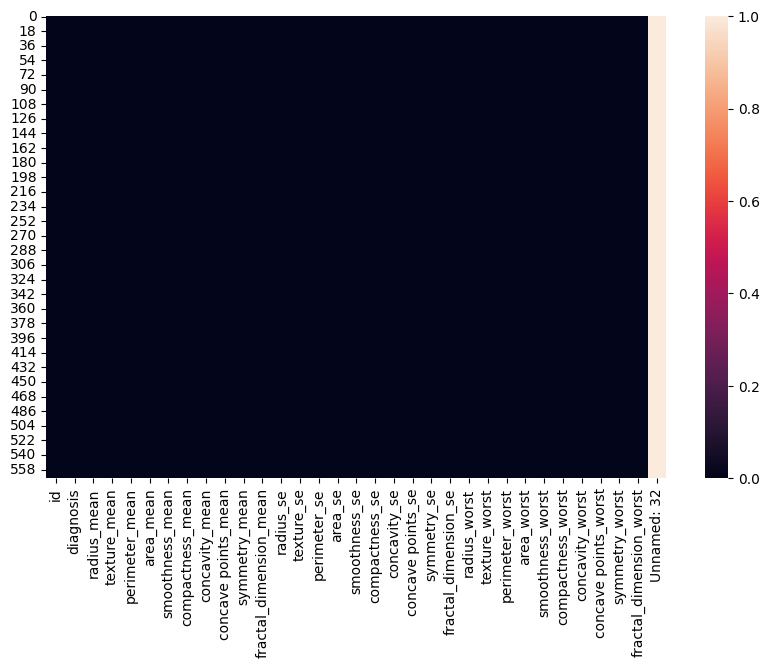

In [136]:
# Verificando valores ausentes com um mapa de calor
plt.figure(figsize=(10, 6))
sns.heatmap(dt.isnull())

### Tarefa 1.4: Realizar a limpeza preliminar (remover colunas `id` e `Unnamed: 32`)

In [137]:
dt = dt.drop(columns=['Unnamed: 32', 'id'])
dt.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<Axes: >

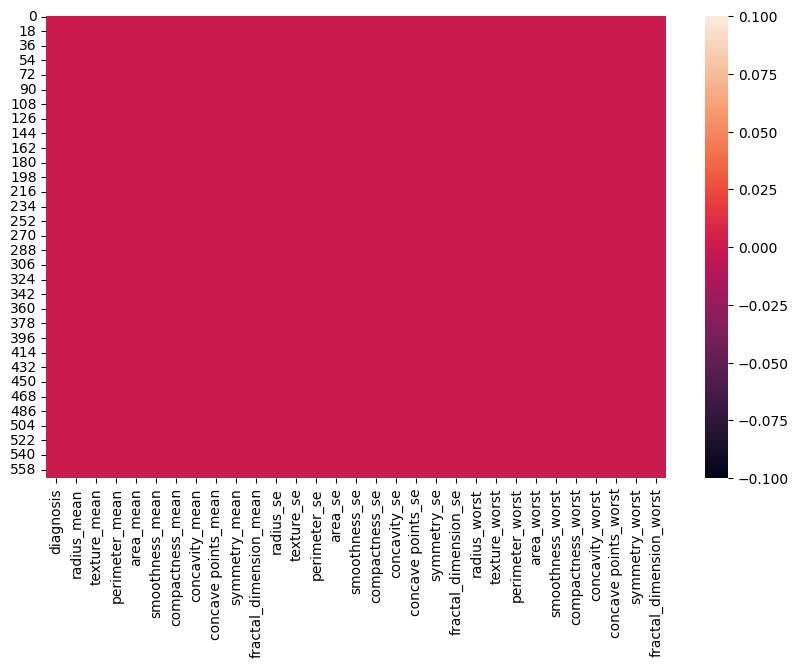

In [138]:
# Resultado da remoção de colunas
plt.figure(figsize=(10, 6))
sns.heatmap(dt.isnull())

## Etapa 2: Análise Exploratória de Dados (EDA)

### Tarefa 2.1 (Análise Univariada): Analisar a distribuição da variável alvo `diagnosis`

**Análise Numérica**
O método .value_counts() é a ferramenta essencial para contar as ocorrências de cada categoria.

In [139]:
counts = dt['diagnosis'].value_counts()
percentages = dt['diagnosis'].value_counts(normalize=True)*100

distribution_df = pd.DataFrame({
    'Contagem': counts,
    'Porcentagem': percentages.map('{:.2f}%'.format) # Formata a coluna de porcentagem
})
print("Distribuição das Classes:")
print(distribution_df)

Distribuição das Classes:
           Contagem Porcentagem
diagnosis                      
B               357      62.74%
M               212      37.26%


 **Análise Visual**
 Um gráfico de contagem (countplot) é a melhor forma de visualizar a distribuição.

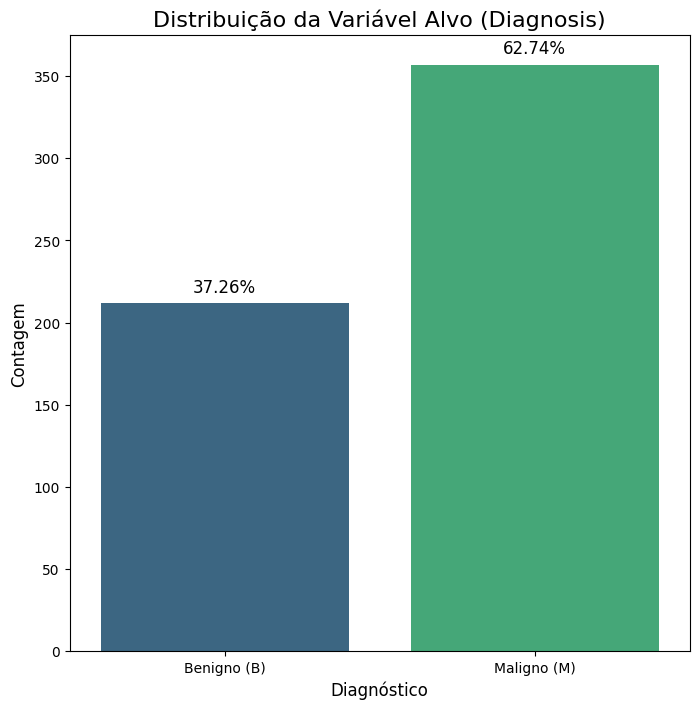

In [140]:

plt.figure(figsize=(8, 8))

total = len(dt)
ax = sns.countplot(x='diagnosis', data=dt, palette='viridis', hue='diagnosis')
for p in ax.patches:
    count = p.get_height()
    # Calcula a porcentagem
    percentage = f'{100 * count / total:.2f}%'
    x = p.get_x() + p.get_width() / 2  # Centro da barra
    y = p.get_height()                 # Topo da barra
    
    # Adiciona o texto usando ax.annotate para mais controle
    ax.annotate(
        text=percentage,
        xy=(x, y),
        xytext=(0, 5), # Deslocamento vertical de 5 pontos
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=12
    )

# Adicionando títulos e rótulos para clareza (seu código original)
plt.title('Distribuição da Variável Alvo (Diagnosis)', fontsize=16)
plt.xlabel('Diagnóstico', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.xticks([0, 1], ['Benigno (B)', 'Maligno (M)'])

plt.show()

In [141]:
dt.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Tarefa 2.2 (Análise Univariada): Analisar a distribuição das features numéricas com histogramas

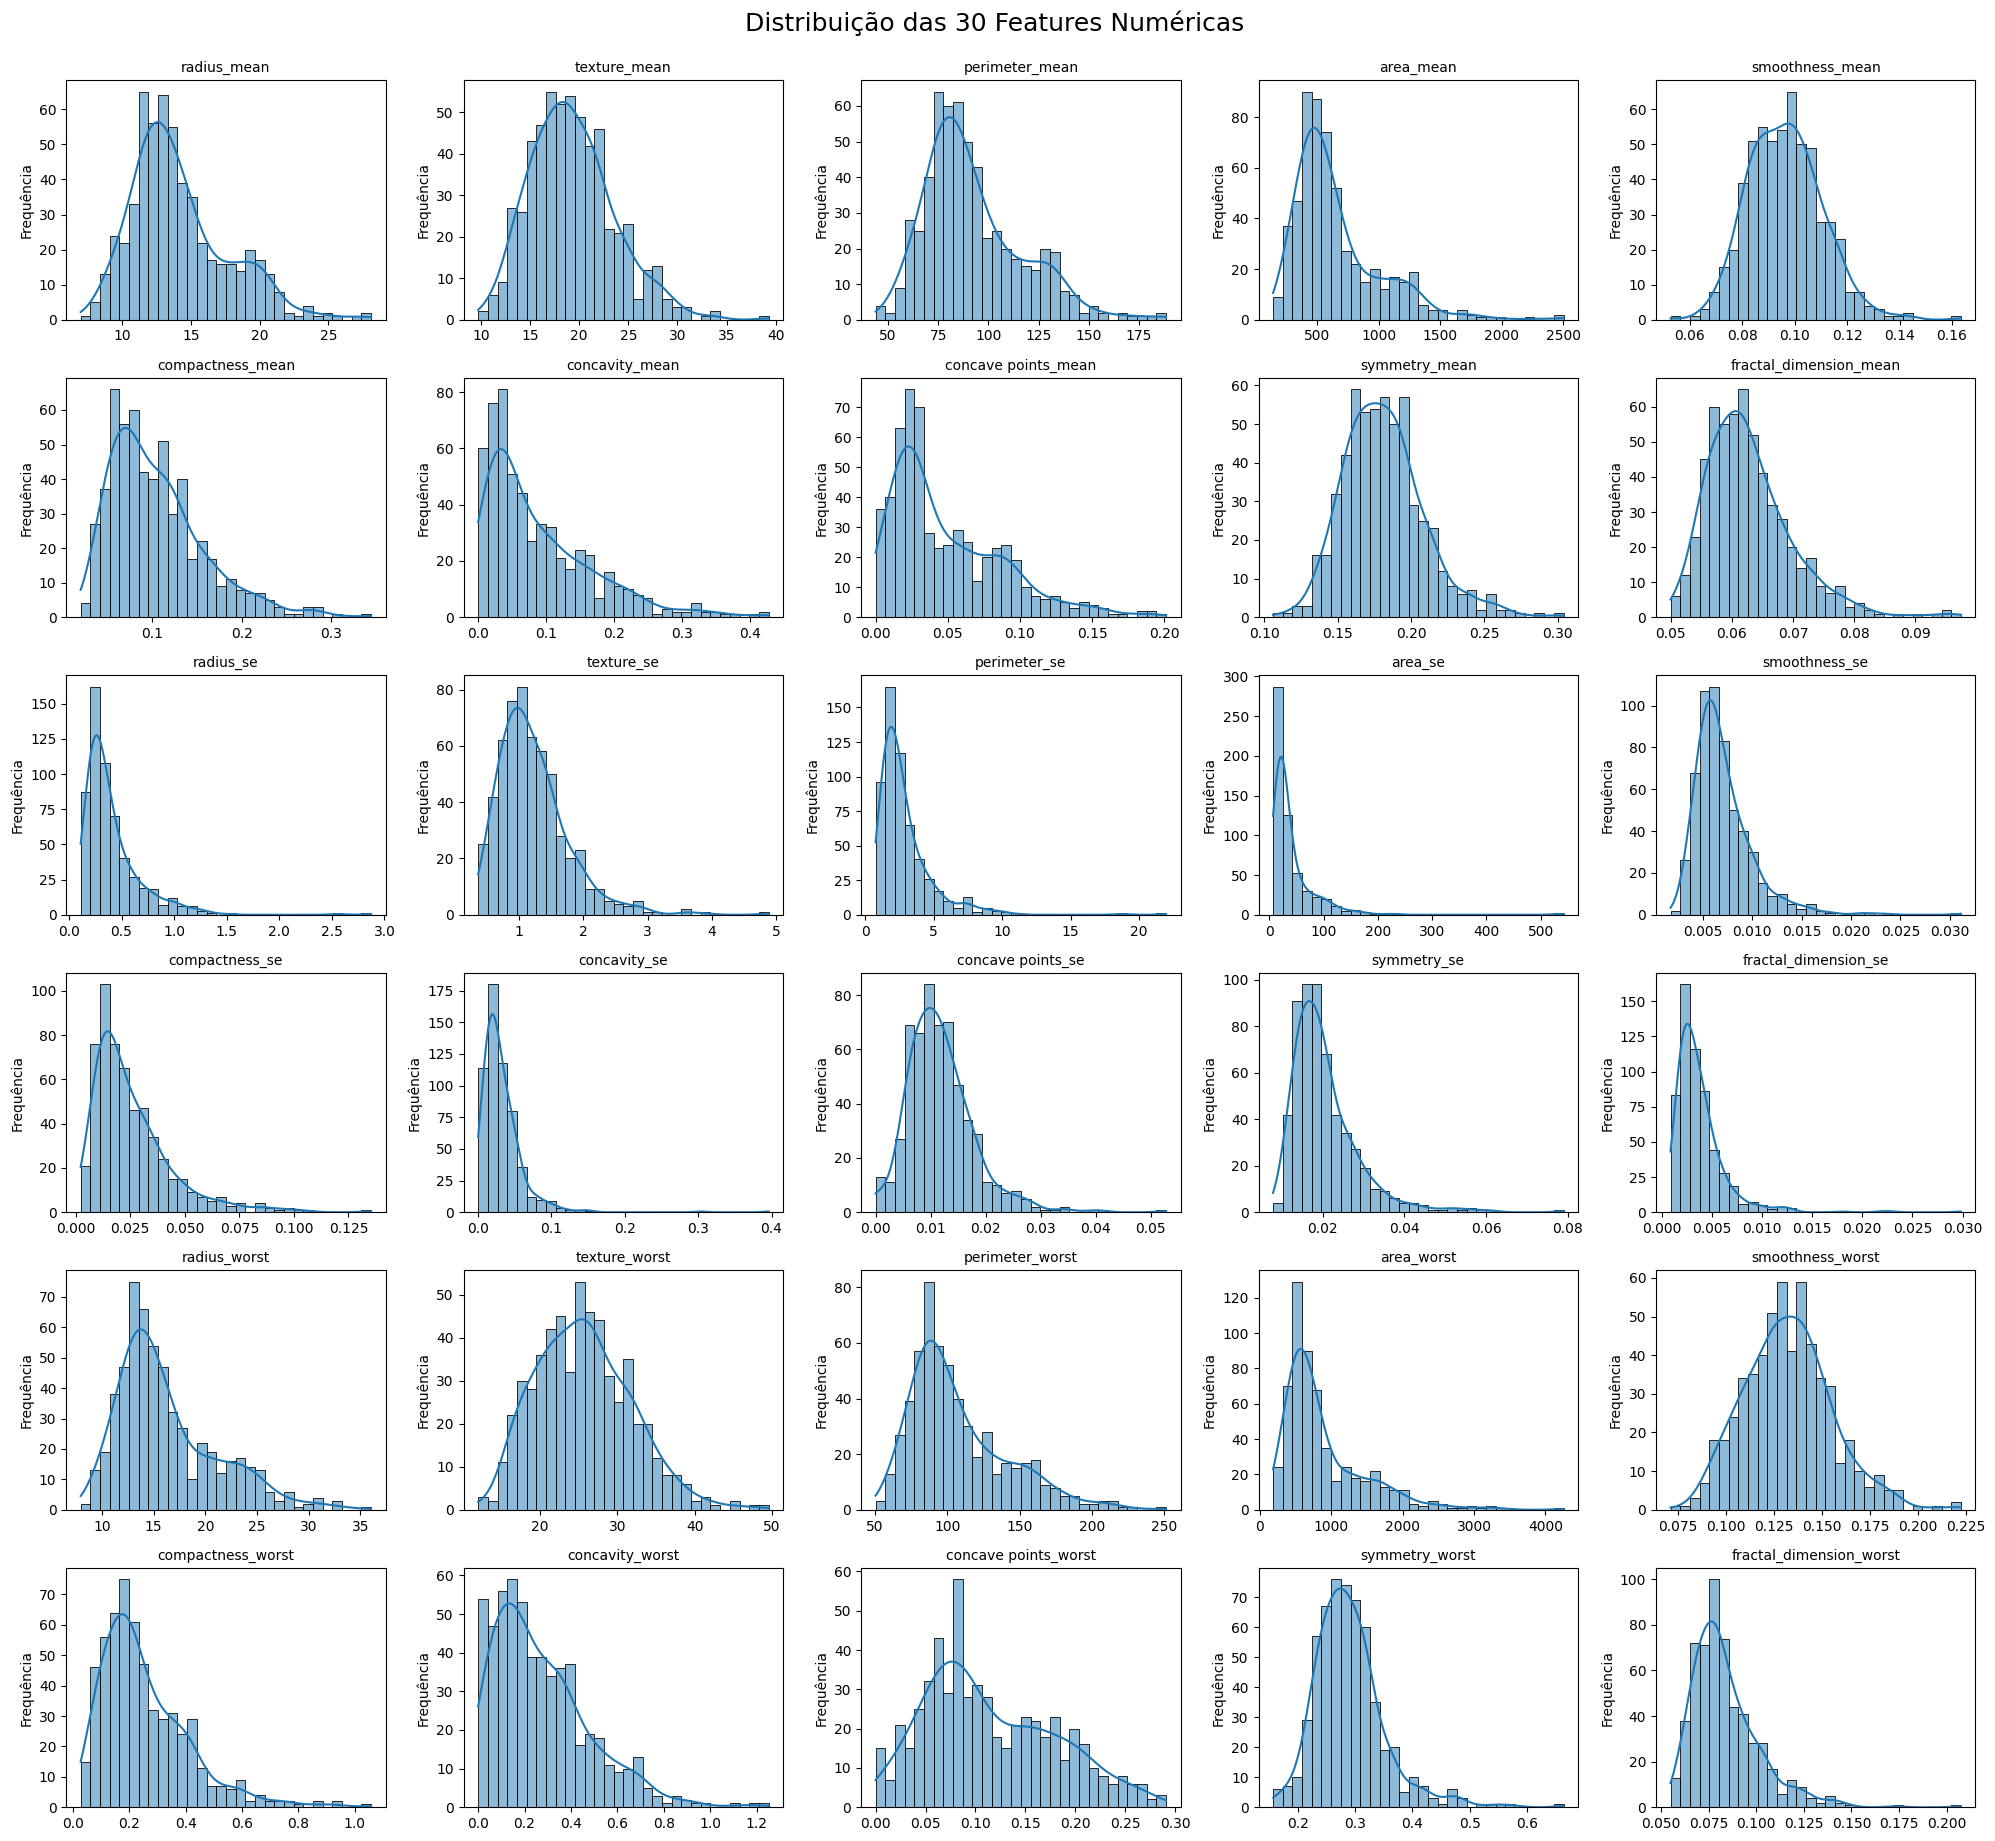

In [173]:
# Tarefa 2.2: Gerar histogramas para todas as 30 features numéricas


# Seleciona apenas as colunas numéricas
features_numericas = dt.select_dtypes(include=[np.number]).columns

# Cria histogramas para cada feature numérica usando programação funcional
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 18))
axes = axes.flatten()
#sns.set_style('whitegrid')

for idx, feature in enumerate(features_numericas):
    # Plota o histograma de cada feature
    sns.histplot(dt[feature], bins=30, ax=axes[idx], kde=True)
    axes[idx].set_title(f"{feature}", fontsize=10)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Frequência')

# Remove eixos não utilizados
for ax in axes[len(features_numericas):]:
    ax.set_visible(False)

plt.tight_layout()
plt.suptitle('Distribuição das 30 Features Numéricas', fontsize=18, y=1.02)
plt.show()

#### Iterpretação Estatística

**Distribuições Assimétricas e Picos**
Muitas variáveis como area_mean, perimeter_mean, radius_mean, concavity_mean, compactness_mean e concave points_mean apresentam distribuições assimétricas, com picos concentrados em valores baixos e caudas longas à direita (distribuição assimétrica positiva). Isso pode indicar que a maioria dos tumores tem características menos agressivas, mas há uma minoria com valores extremos que podem estar associados a casos malignos.

**Variáveis com Distribuição Quase Normal**
Variáveis como texture_mean, smoothness_mean, symmetry_mean e fractal_dimension_mean parecem ter distribuições mais simétricas, próximas de uma normal. Essas variáveis podem ser menos discriminativas isoladamente, mas úteis em combinação com outras.

**Variáveis com Baixa Variabilidade**
Algumas variáveis como fractal_dimension_se e smoothness_se têm histogramas muito estreitos, indicando baixa variabilidade. Podem ter menor poder preditivo ou exigir normalização cuidadosa para evitar viés no modelo.

**Sufixos _mean, _se, _worst**
Esses sufixos indicam diferentes aspectos da mesma característica:
 - _mean: média dos valores
 - _se: erro padrão
 - _worst: valor mais extremo observado
Os valores _worst tendem a ter distribuições mais amplas e assimétricas, sugerindo que podem ser bons indicadores de malignidade.



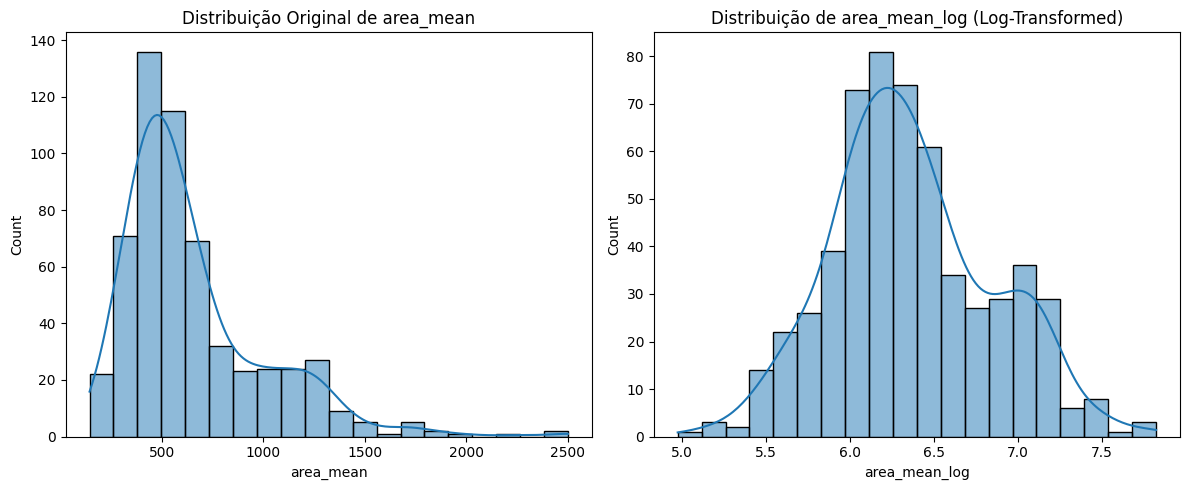

In [143]:
import numpy as np

# Exemplo de como transformar uma feature assimétrica (ex: area_mean)
dt['area_mean_log'] = np.log1p(dt['area_mean'])

# Plotando o antes e o depois para ver o efeito
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes da transformação
sns.histplot(dt['area_mean'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Distribuição Original de area_mean')

# Depois da transformação
sns.histplot(dt['area_mean_log'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de area_mean_log (Log-Transformed)')

plt.tight_layout()
plt.show()

In [144]:
dt.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,area_mean_log
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,6.909753
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,7.190676
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,7.093405
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,5.958683
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,7.168580


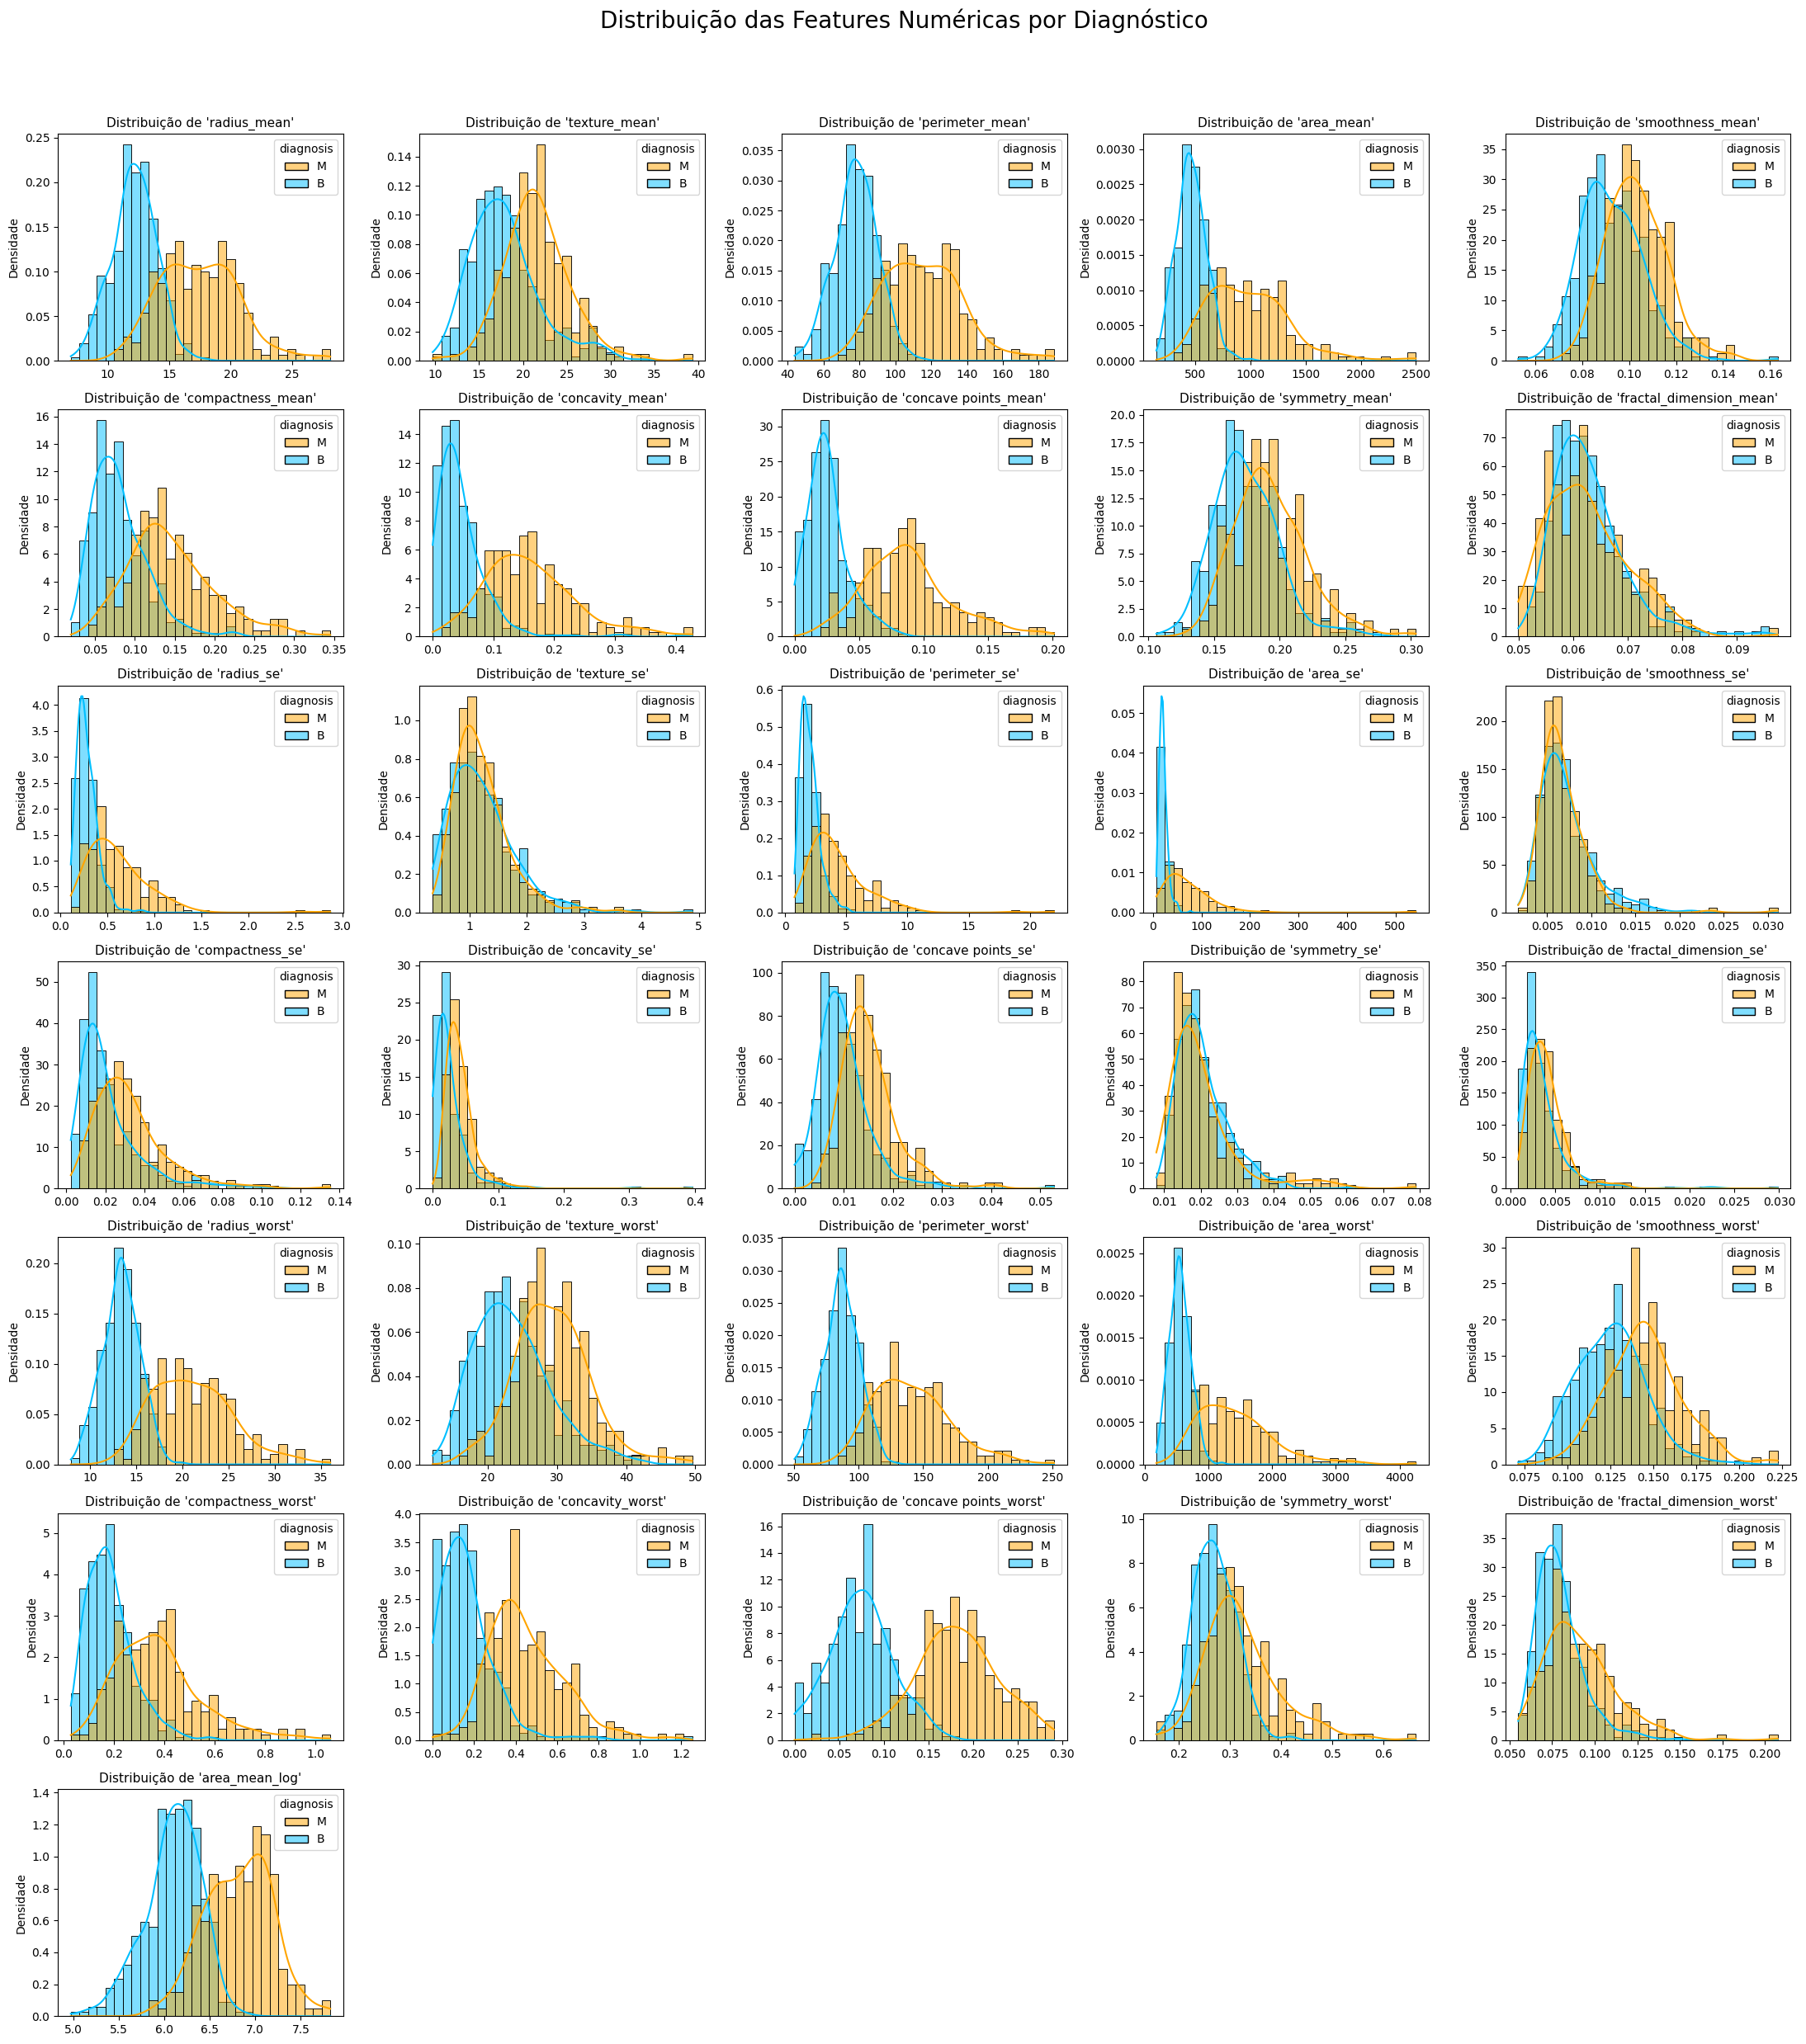

In [145]:

# Seleciona apenas as colunas numéricas. A coluna 'diagnosis' (object) será ignorada.
features_numericas = dt.select_dtypes(include=[np.number]).columns

# Cria a figura e os eixos para os subplots
# Ajusta para 7 linhas x 5 colunas para acomodar todas as 31 features
fig, axes = plt.subplots(nrows=7, ncols=5, figsize=(22, 24))
axes = axes.flatten() # Transforma a matriz de eixos em um array 1D

# Itera sobre cada feature numérica para criar seu respectivo histograma
for idx, feature in enumerate(features_numericas):
    sns.histplot(
        data=dt,                 
        x=feature,               
        hue='diagnosis',         # SEPARA E COLORE os dados pela coluna 'diagnosis'
        bins=30,                 
        ax=axes[idx],            
        kde=True,                
        stat='density',          
        common_norm=False,
        palette={'B': 'deepskyblue', 'M': 'orange'} # Mapeia os valores 'B' e 'M' para cores
    )
    axes[idx].set_title(f"Distribuição de '{feature}'", fontsize=11)
    axes[idx].set_xlabel('')      
    axes[idx].set_ylabel('Densidade')
    
# Remove os eixos que não foram utilizados
for ax in axes[len(features_numericas):]:
    ax.set_visible(False)

# Adiciona um título geral e ajusta o layout
plt.suptitle('Distribuição das Features Numéricas por Diagnóstico', fontsize=20, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 1]) 
plt.show()

#### Interpretação

**Raio, Perímetro e Área**
Os casos malignos tendem a ter valores mais altos nessas três variáveis.
Isso sugere que tumores malignos geralmente são maiores e mais irregulares.

**Textura**
A distribuição é mais sobreposta, mas ainda assim os malignos mostram uma leve tendência a valores mais altos.
Pode indicar heterogeneidade maior em tecidos malignos.

**Suavidade e Simetria**
As distribuições são mais próximas entre benignos e malignos.
Menor poder discriminativo isoladamente.

**Compacidade, Concavidade e Pontos Côncavos**
Fortemente deslocados para valores maiores nos casos malignos.
São bons indicadores de irregularidade na forma do tumor.

**Dimensão Fractal**
Diferença sutil, mas ainda com tendência a valores maiores em malignos.
Pode refletir complexidade estrutural do tumor.


___ 

A visualização anterior nos mostrou a forma geral de cada feature, onde notamos indícios de bimodalidade (dois picos). Esta nova visualização confirma a nossa hipótese e nos mostra o porquê dessa forma: os dois picos correspondem, de fato, às distribuições distintas das classes Benigna (B) e Maligna (M). Ao sobrepor os histogramas, passamos de uma simples análise de distribuição para uma poderosa análise de separabilidade, que nos permite avaliar visualmente o poder preditivo de cada feature individualmente.


**Preditores de Alta Performance (Excelente Separação)**
Estas são as features onde as distribuições azul (Benigno) e laranja (Maligno) têm pouquíssima sobreposição. Os picos estão em locais claramente distintos, e a cauda de uma distribuição mal invade a área da outra.
Exemplos Notáveis: concave points_mean, perimeter_worst, radius_worst, area_worst, concave points_worst.
Análise Comparativa: Na análise anterior, vimos que estas features eram bimodais. Agora, confirmamos que o pico esquerdo corresponde aos tumores benignos e o pico/ombro direito, aos malignos. Os valores para tumores malignos são consistentemente mais altos.


**Preditores Moderados (Separação Razoável)**
Neste grupo, as distribuições se sobrepõem consideravelmente, mas seus picos (médias) ainda estão em locais visivelmente diferentes.
Exemplos Notáveis: texture_mean, area_se, smoothness_worst, compactness_worst.
Análise Comparativa: A texture_mean, que na análise anterior parecia quase normal, agora revela sua utilidade: embora haja muita sobreposição, a distribuição dos tumores malignos (laranja) está claramente deslocada para a direita, indicando que valores de textura mais altos são mais associados à malignidade.

**Preditores de Baixa Performance (Muita Sobreposição)**
Aqui, as distribuições azul e laranja estão quase perfeitamente uma sobre a outra. Seus picos e formas são muito semelhantes.
Exemplos Notáveis: fractal_dimension_mean, symmetry_se, smoothness_se, fractal_dimension_se.
Análise Comparativa: Estas features, que já pareciam ter baixa variabilidade na análise anterior, agora se mostram pouco úteis isoladamente.



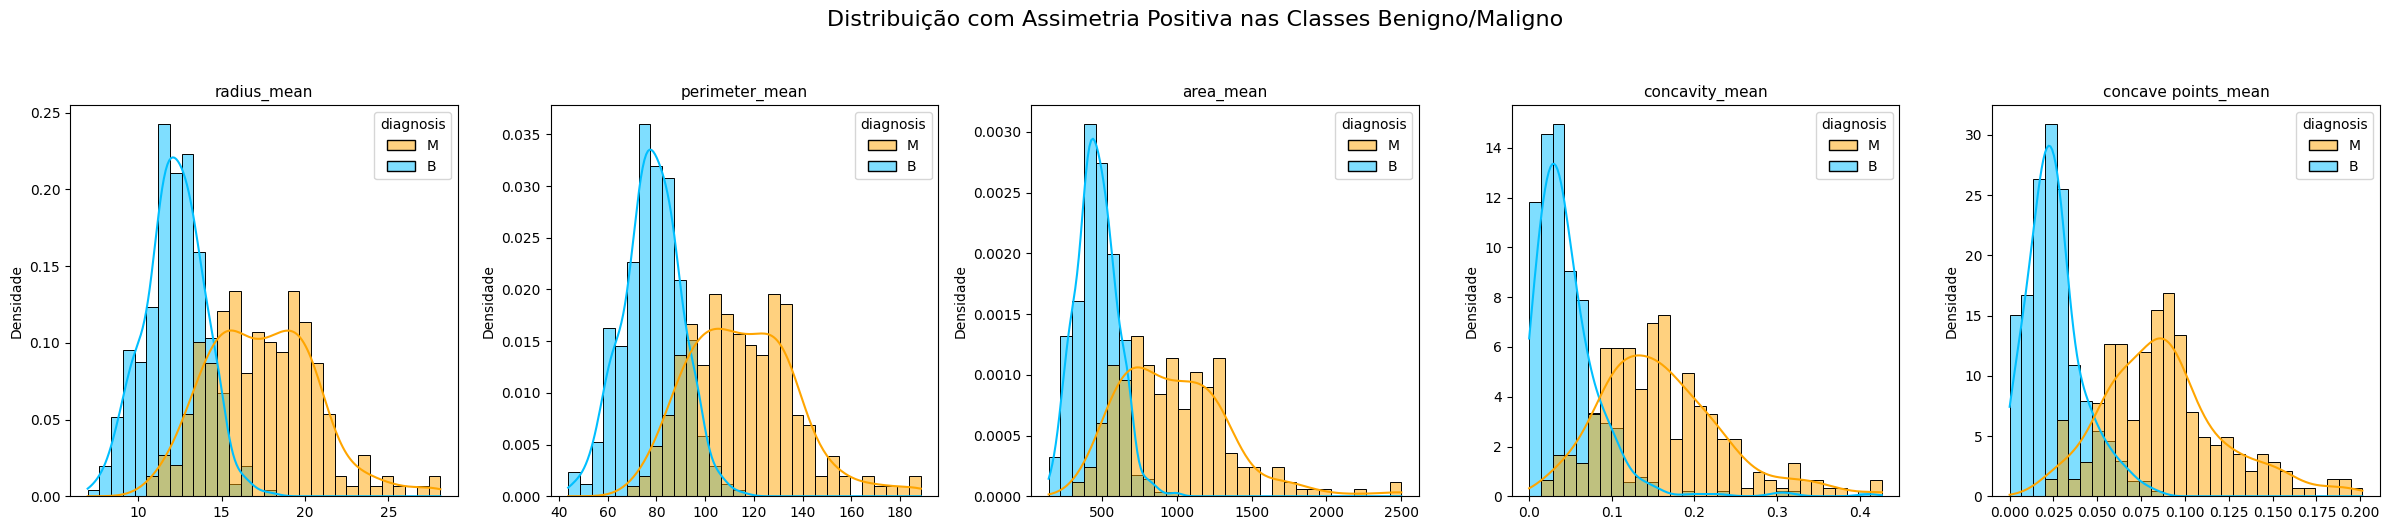

In [175]:
# Destacar histogramas com assimetria positiva

import matplotlib.pyplot as plt
import seaborn as sns

# Lista das 5 variáveis com maior assimetria nos casos malignos
features_destacadas = ['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean']

# Cria a figura com subplots
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(24, 5))
axes = axes.flatten()

for idx, feature in enumerate(features_destacadas):
    sns.histplot(
        data=dt,
        x=feature,
        hue='diagnosis',
        bins=30,
        kde=True,
        stat='density',
        common_norm=False,
        ax=axes[idx],
        palette={'B': 'deepskyblue', 'M': 'orange'}
    )
    axes[idx].set_title(f"{feature}", fontsize=11)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Densidade')

plt.suptitle('Distribuição com Assimetria Positiva nas Classes Benigno/Maligno', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Análise de Simetria e Picos por Diagnóstico

Ao analisar os histogramas sobrepostos por diagnóstico, nota-se que:

#### 📈 Assimetria
Várias variáveis apresentam **assimetria positiva** (cauda à direita), especialmente nos casos **malignos**. Exemplos claros:
- `radius_mean`, `perimeter_mean`, `area_mean`, `concavity_mean`, `concave points_mean`  
  → Tumores malignos concentram-se em valores mais altos e com maior dispersão, gerando assimetrias visíveis.



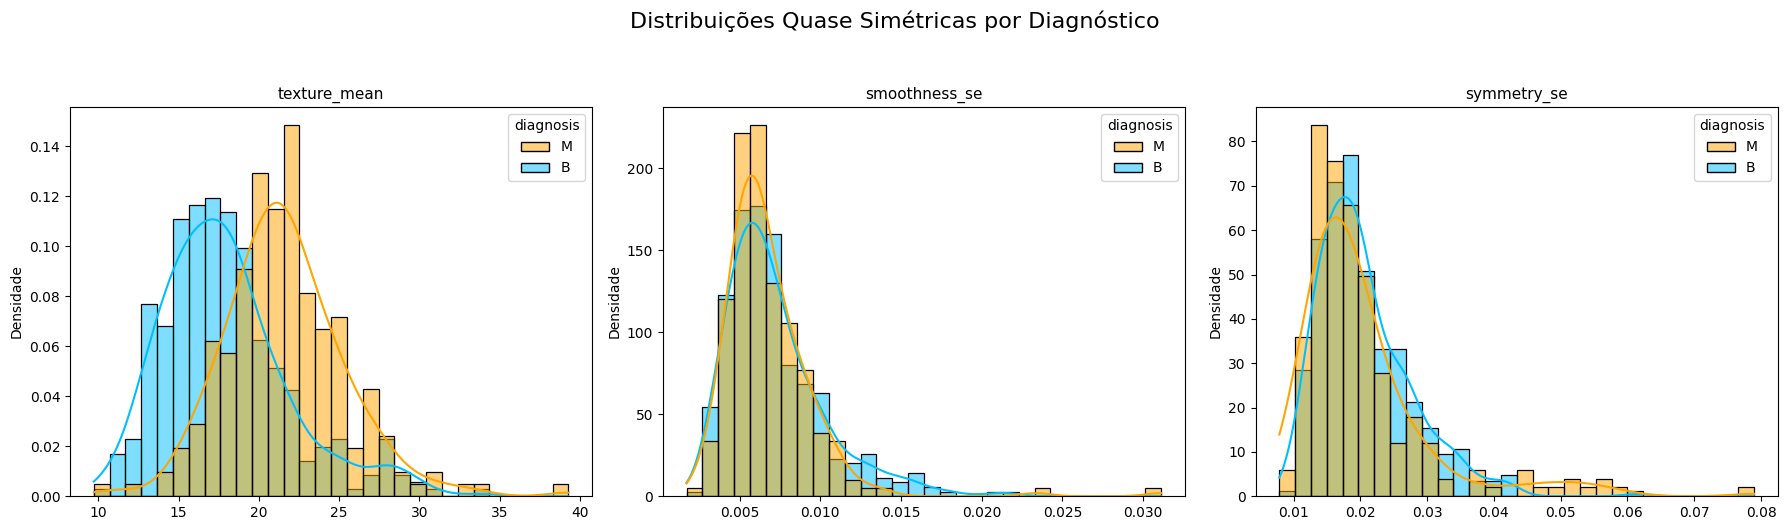

In [176]:
# Plotar variáveis com distribuições quase simétricas

import matplotlib.pyplot as plt
import seaborn as sns

features_simetricas = ['texture_mean', 'smoothness_se', 'symmetry_se']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
axes = axes.flatten()

for idx, feature in enumerate(features_simetricas):
    sns.histplot(
        data=dt,
        x=feature,
        hue='diagnosis',
        bins=30,
        kde=True,
        stat='density',
        common_norm=False,
        ax=axes[idx],
        palette={'B': 'deepskyblue', 'M': 'orange'}
    )
    axes[idx].set_title(f"{feature}", fontsize=11)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Densidade')

plt.suptitle('Distribuições Quase Simétricas por Diagnóstico', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Simetria
Já variáveis como `texture_mean`, `smoothness_se` e `symmetry_se` mantêm distribuições **quase simétricas** para ambos os diagnósticos, sugerindo menor variabilidade ou pouca separação entre as classes.

Essas diferenças reforçam que certas variáveis têm **alto potencial preditivo individual**, enquanto outras não agregam separação clara entre classes.




### Tarefa 2.3 (Análise Bivariada): Analisar a relação entre as features e a variável alvo com boxplots

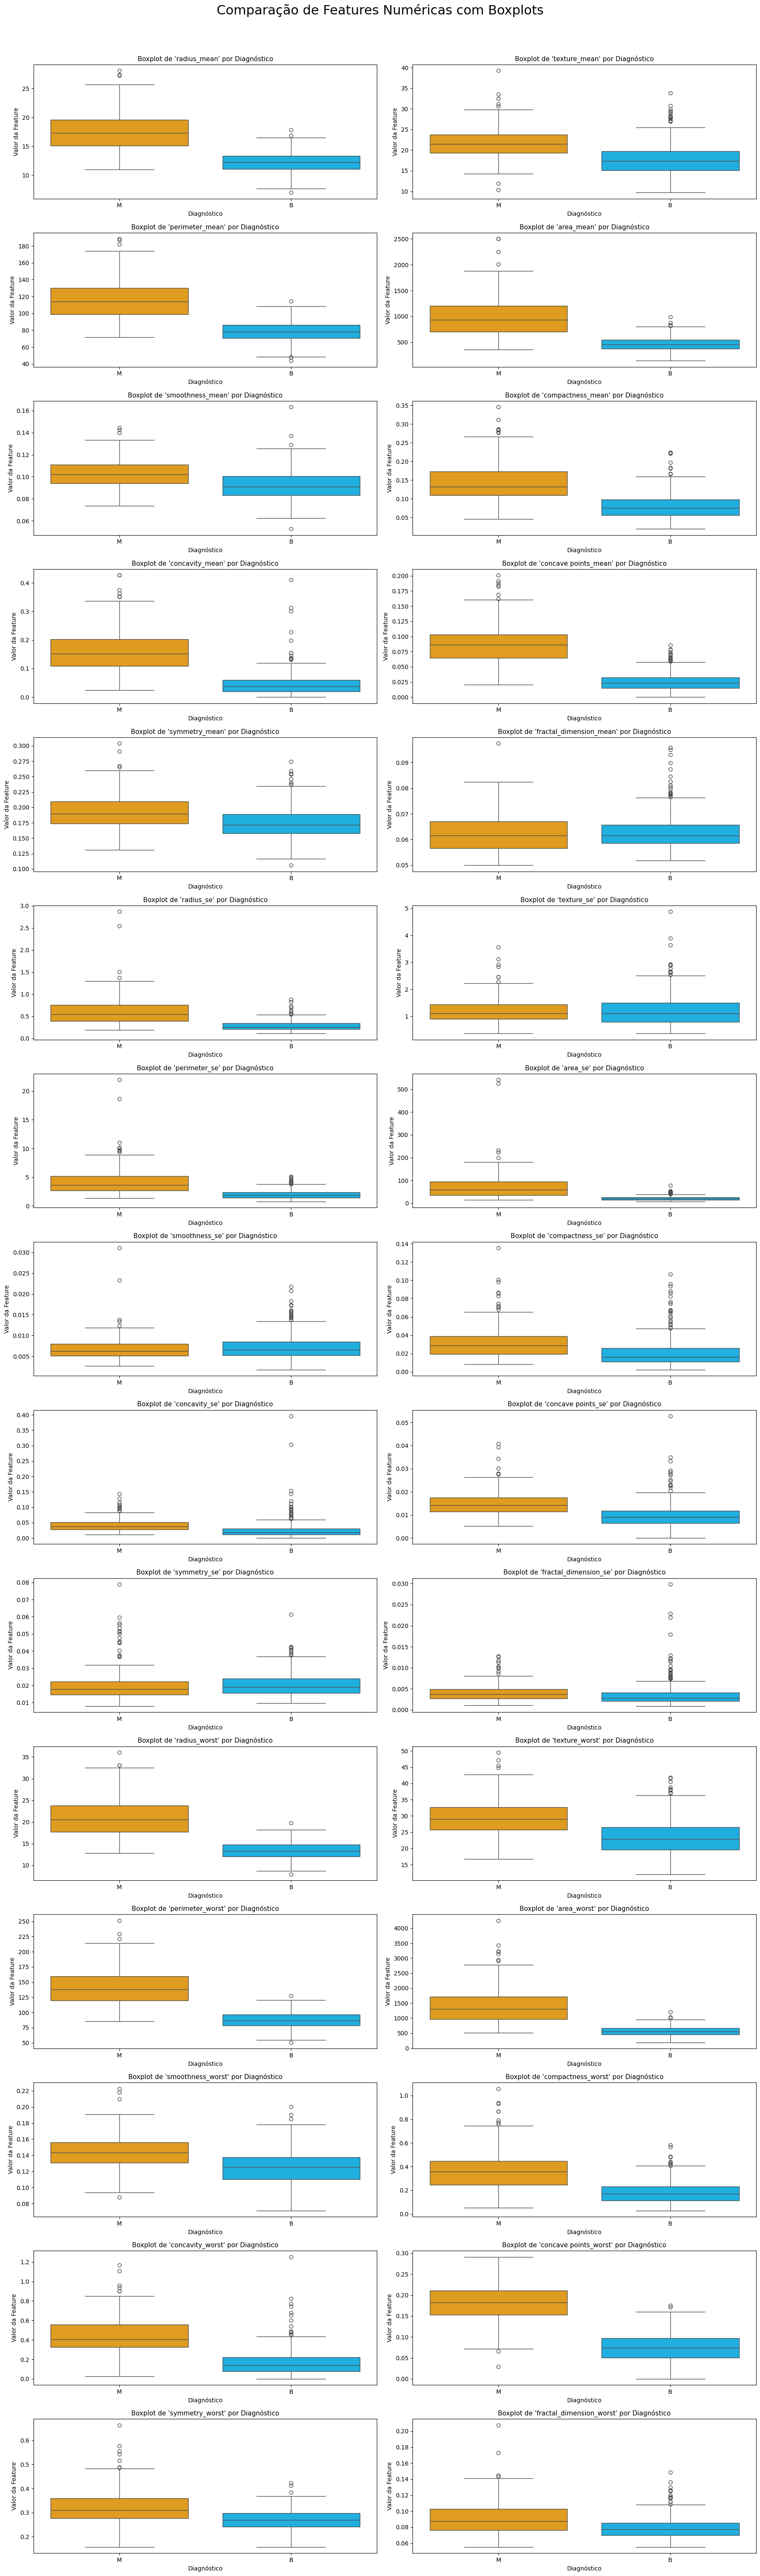

In [174]:
features_numericas = dt.select_dtypes(include=[np.number]).columns
n_colunas = 2
n_linhas = int(np.ceil(len(features_numericas) / n_colunas))

fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(18, n_linhas * 4))
axes = axes.flatten()


for idx, feature in enumerate(features_numericas):
    sns.boxplot(
        data=dt,
        x='diagnosis', 
        hue='diagnosis',    # A variável categórica no eixo X cria os grupos
        y=feature,      # A variável numérica no eixo Y
        ax=axes[idx],   # Define em qual subplot desenhar
        palette={'B': 'deepskyblue', 'M': 'orange'} # Mesma paleta de cores
    )
    axes[idx].set_title(f"Boxplot de '{feature}' por Diagnóstico", fontsize=11)
    axes[idx].set_xlabel('Diagnóstico') # Rótulo do eixo X
    axes[idx].set_ylabel('Valor da Feature') # Rótulo do eixo Y

# Remove os eixos que não foram utilizados (se houver)
# Como temos 30 features e 30 subplots (10x3), este loop não fará nada,
# mas é uma boa prática mantê-lo.
for ax in axes[len(features_numericas):]:
    ax.set_visible(False)

# Adiciona um título geral e ajusta o layout
plt.suptitle('Comparação de Features Numéricas com Boxplots', fontsize=22, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

#### Interpretação 

**Preditores de Alta Performance (Separação Drástica**
Estas são as features onde a caixa laranja (Maligno) e a caixa azul (Benigno) praticamente não se sobrepõem. A mediana dos tumores malignos é frequentemente maior do que o valor máximo (o topo do "bigode") dos tumores benignos.
Exemplos Notáveis: concave points_worst, perimeter_worst, radius_worst, concave points_mean, area_mean.
Análise: Para a feature concave points_worst, por exemplo, a grande maioria dos tumores benignos tem valores abaixo de 0.1, enquanto a grande maioria dos tumores malignos tem valores acima de 0.15. A separação é quase perfeita.

 **Preditores Moderados (Separação Estatística Clara)**
Neste grupo, as caixas se sobrepõem, mas suas posições (medianas) e/ou tamanhos (dispersão) são visivelmente diferentes.
Exemplos Notáveis: texture_mean, smoothness_worst, symmetry_worst.
Análise: Observe a texture_mean. Embora haja uma sobreposição considerável, a caixa laranja (M) está claramente posicionada em valores mais altos que a caixa azul (B). Isso nos diz que, estatisticamente, tumores malignos tendem a ter uma textura maior.

 **Preditores de Baixa Performance (Alta Sobreposição)**
Aqui, as caixas e as medianas estão em posições muito semelhantes, indicando que a distribuição da feature é quase idêntica para ambos os diagnósticos.
Exemplos Notáveis: fractal_dimension_se, smoothness_se.
Análise: Os boxplots para fractal_dimension_se são praticamente indistinguíveis entre si.





### Tarefa 2.4 (Análise Bivariada): Analisar a correlação entre as features numéricas com um heatmap

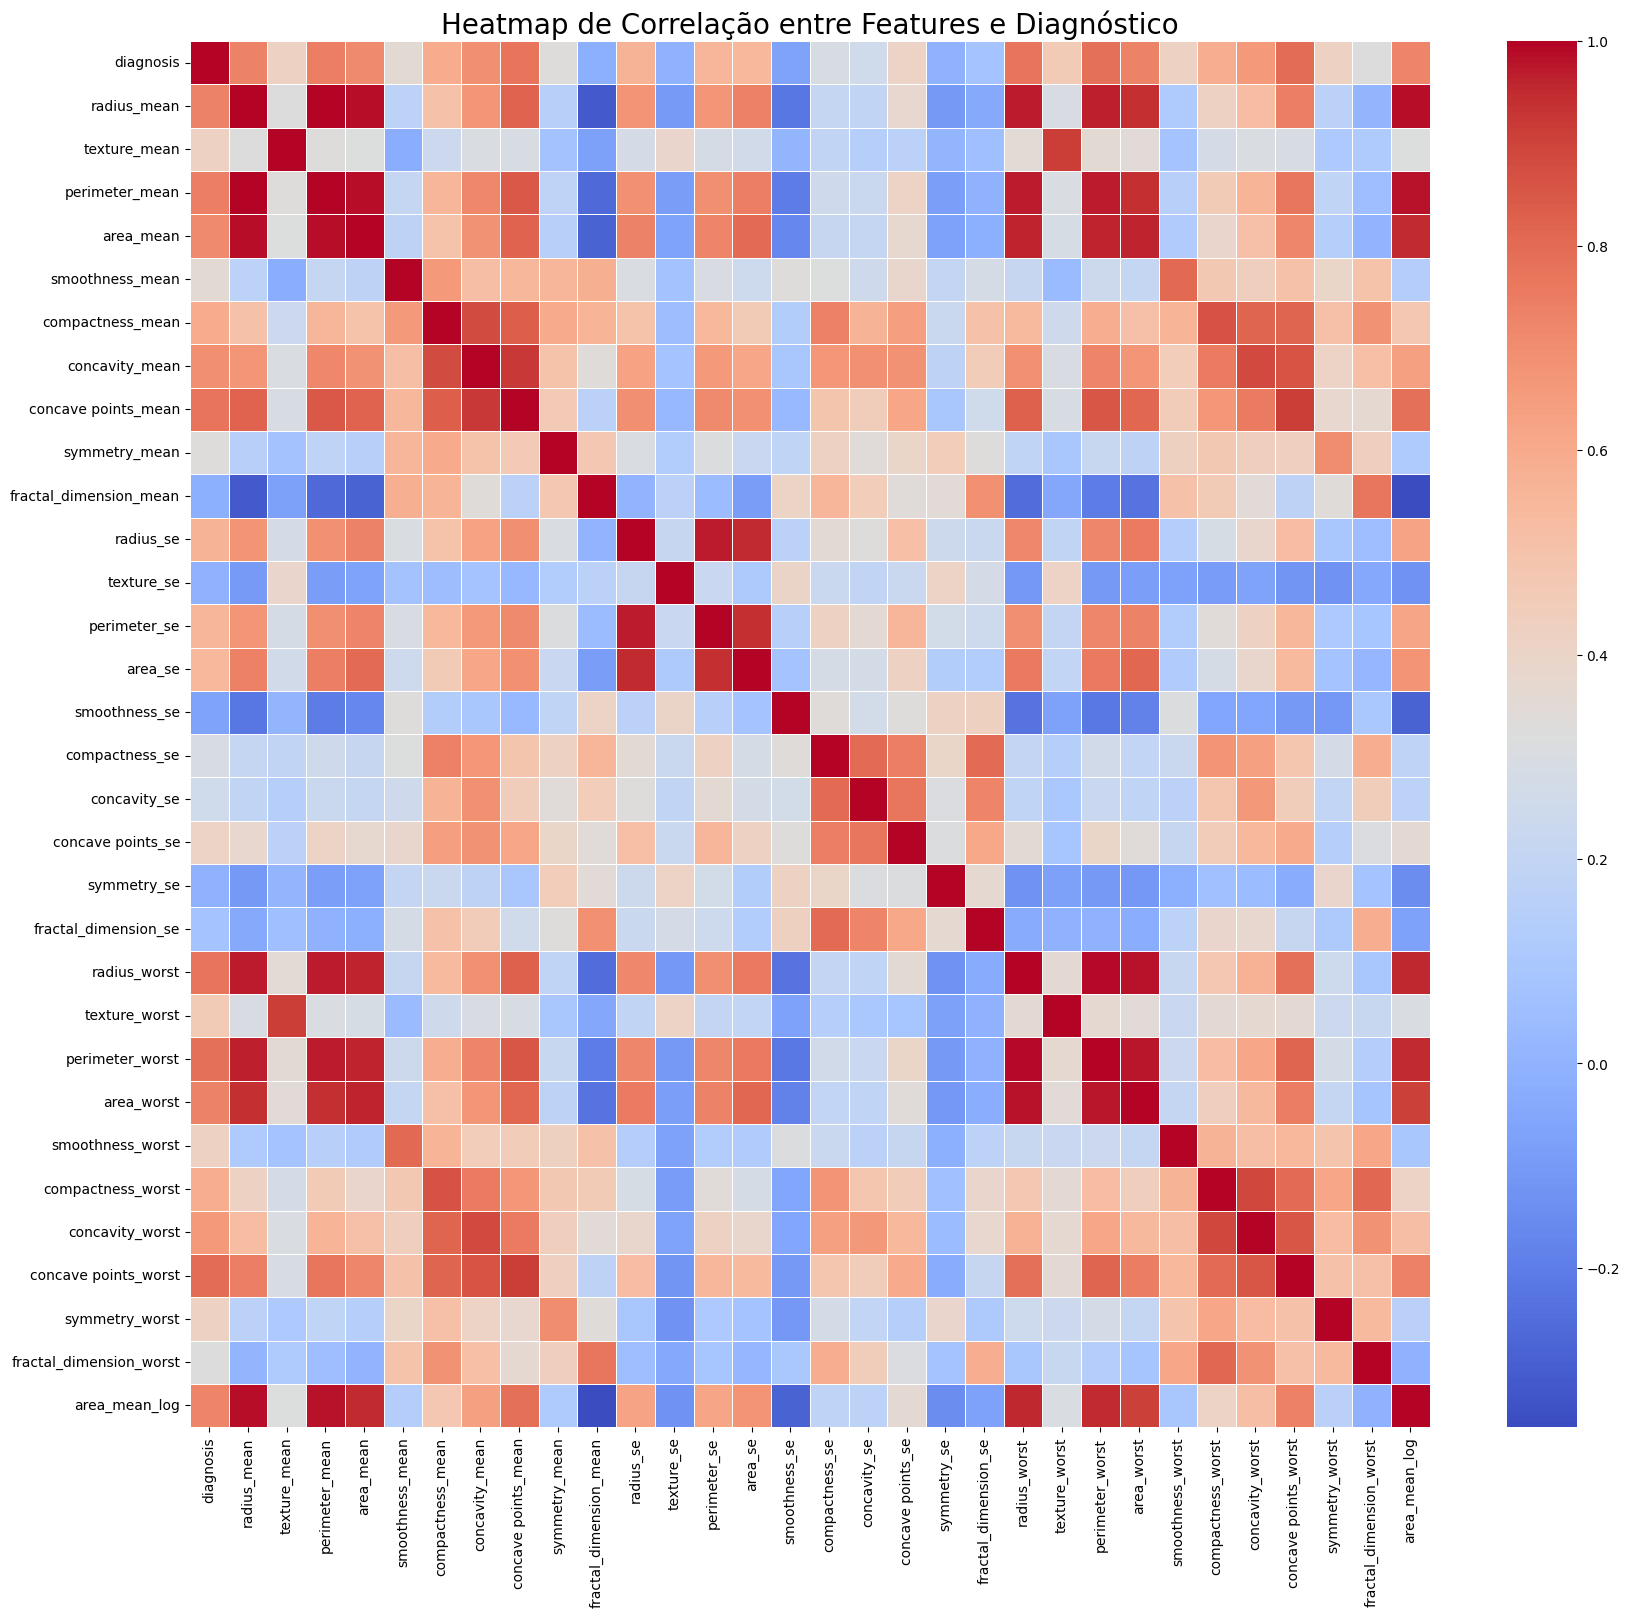

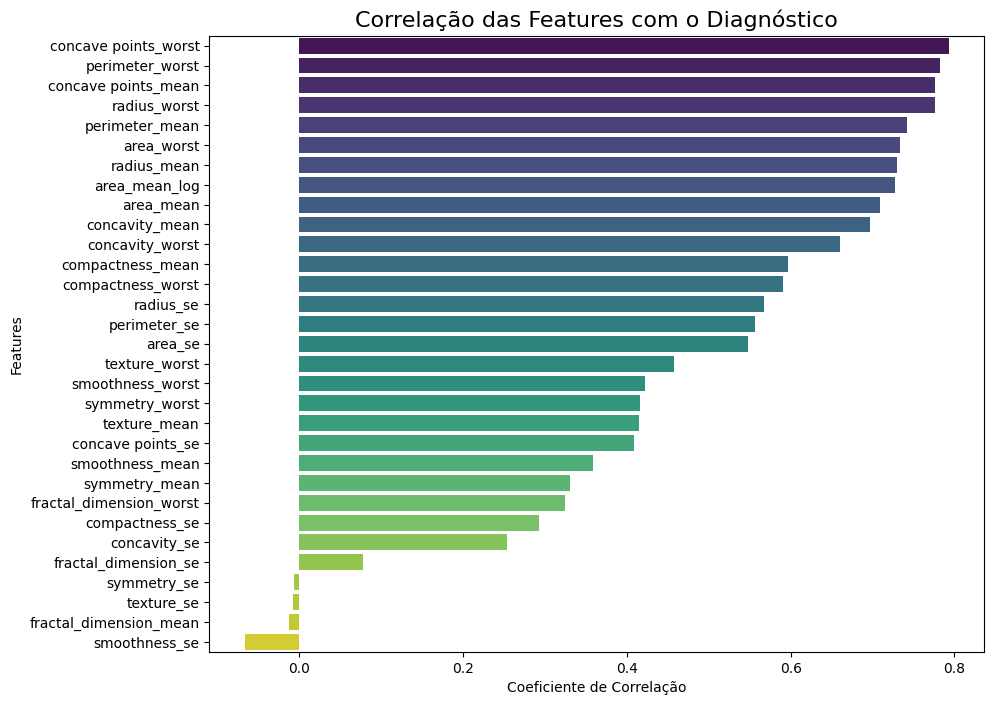

concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean_log              0.727979
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

In [147]:

# 1. Criar uma cópia do DataFrame para não alterar o original
df_corr = dt.copy()

# 2. Converter a coluna 'diagnosis' para formato numérico
#    Mapeamos Maligno (M) para 1 e Benigno (B) para 0
df_corr['diagnosis'] = df_corr['diagnosis'].map({'M': 1, 'B': 0})

# 3. Calcular a matriz de correlação
#    O .corr() agora incluirá a coluna 'diagnosis'
correlation_matrix = df_corr.corr()

# 4. Gerar o heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(
    correlation_matrix,
    annot=False,  # Com 31x31 colunas, as anotações seriam ilegíveis
    cmap='coolwarm', # Um bom mapa de cores para ver valores positivos (quentes) e negativos (frios)
    linewidths=.5
)
plt.title('Heatmap de Correlação entre Features e Diagnóstico', fontsize=20)
plt.show()

# 5. (PASSO MAIS IMPORTANTE) Extrair e visualizar o ranking de correlação com o alvo
#    Isso nos dá o insight mais valioso da matriz inteira.
target_correlation = correlation_matrix['diagnosis'].drop('diagnosis').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=target_correlation.values, y=target_correlation.index, palette='viridis')
plt.title('Correlação das Features com o Diagnóstico', fontsize=16)
plt.xlabel('Coeficiente de Correlação')
plt.ylabel('Features')
plt.show()

print(target_correlation)

#### Interpretação

**Correlação Feature-Alvo (O Ranking dos Preditores)**
Elas confirmam numericamente o que vimos visualmente nos histogramas e boxplots.
- Preditores de Alta Performance (Correlação Forte, > 0.7):
    - Features: concave points_worst, perimeter_worst, concave points_mean, radius_worst, etc.
    - Análise: Todas estas features têm uma forte correlação positiva com o diagnóstico. Isso significa que, à medida que o valor dessas features aumenta, a probabilidade de o diagnóstico ser Maligno (mapeado para 1) também aumenta. Isso alinha-se perfeitamente com os boxplots, onde vimos que as "caixas" dos tumores Malignos estavam em posições muito mais altas para estas mesmas features.
- Preditores de Baixa Performance (Correlação Próxima de Zero):
    - Features: symmetry_se, texture_se, fractal_dimension_mean, smoothness_se.
    - Análise: Os coeficientes de correlação são quase nulos (-0.06 a 0.07). Isso indica que não há uma relação linear discernível entre estas features e o diagnóstico. Novamente, isso valida o que vimos nos gráficos anteriores, onde as distribuições para Benigno e Maligno estavam quase completamente sobrepostas.

**Correlação Feature-Feature (O Problema da Multicolinearidade)**
Agora, vamos olhar para o heatmap em si, ignorando a primeira linha/coluna (diagnosis).
- Observação: Note os grandes "quadrados" de vermelho vivo (correlação próxima de +1.0) na matriz.
Um exemplo gritante é o bloco entre radius_mean, perimeter_mean, e area_mean. Eles são quase perfeitamente correlacionados.
O mesmo padrão se repete para suas contrapartes _worst (radius_worst, perimeter_worst, area_worst).
- Análise (O "Porquê"): Isso é esperado e lógico. Raio, perímetro e área são medidas geometricamente relacionadas da mesma característica subjacente: o tamanho do tumor. Se um aumenta, os outros aumentam de forma previsível. Elas são redundantes, pois carregam essencialmente a mesma informação.

### Tarefa 2.5 (Análise Multivariada): Analisar a separabilidade das classes com PCA

In [148]:

# 1. Separar as features (X) da variável alvo (y)
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis']

# 2. (PASSO CRUCIAL) Escalonar as features
#    O PCA funciona melhor quando todas as features têm média 0 e desvio padrão 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar o PCA
#    Vamos reduzir as 30 features para apenas 2 componentes principais.
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# 4. Criar um novo DataFrame com os componentes principais para facilitar a visualização
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
# Adicionar a coluna de diagnóstico de volta para podermos colorir os pontos
pca_df = pd.concat([pca_df, y], axis=1)






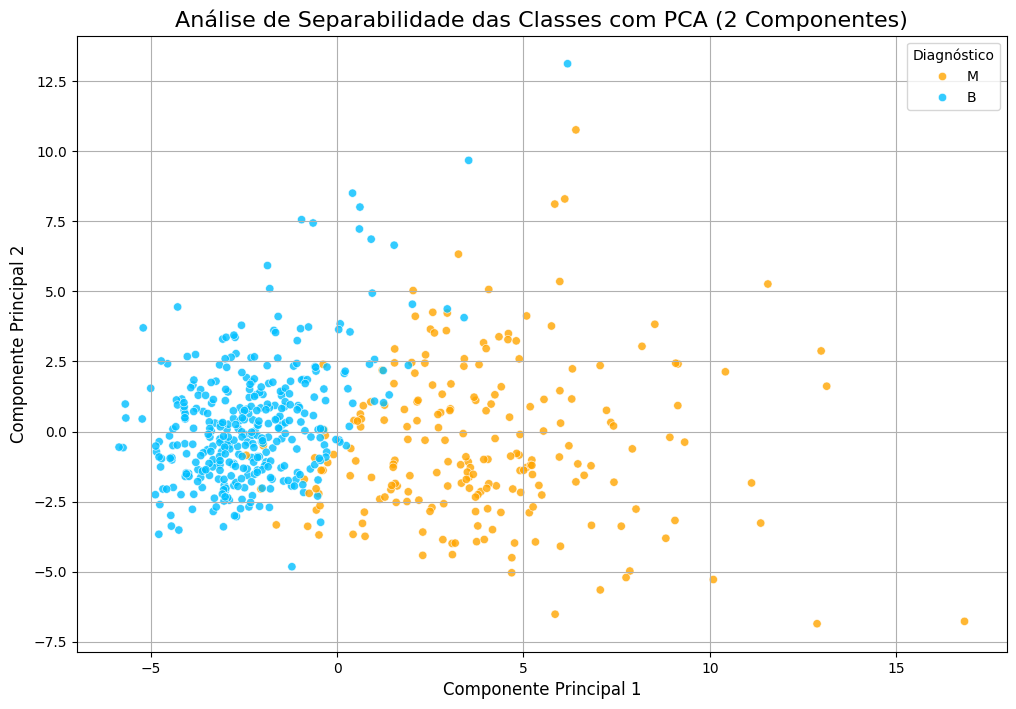

Variância explicada por PC1: 44.81%
Variância explicada por PC2: 19.36%
Variância total explicada pelos 2 componentes: 64.17%


In [149]:

# 7. Visualizar o resultado
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='diagnosis', 
    data=pca_df, 
    palette={'B': 'deepskyblue', 'M': 'orange'},
    alpha=0.8
)

plt.title('Análise de Separabilidade das Classes com PCA (2 Componentes)', fontsize=16)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Diagnóstico')
plt.grid()
plt.show()

# (Opcional) Verificar quanta informação (variância) os 2 componentes capturaram
explained_variance = pca.explained_variance_ratio_
print(f"Variância explicada por PC1: {explained_variance[0]:.2%}")
print(f"Variância explicada por PC2: {explained_variance[1]:.2%}")
print(f"Variância total explicada pelos 2 componentes: {np.sum(explained_variance):.2%}")

#### Interpretação

**PC1 (Primeiro Componente Principal):**
É a combinação linear das variáveis originais que captura a maior parte da variância dos dados.
→ No caso, PC1 sozinho explica 44,81% da variabilidade total do dataset.

**PC2 (Segundo Componente Principal):**
É a segunda combinação linear, ortogonal (independente) de PC1, que captura a segunda maior parte da variância.
→ Aqui, PC2 explica 19,36% da variância.

**Variância total**
A variância total explicada pelos dois primeiros componentes (PC1 + PC2) é 64,17%.
Isso quer dizer que, ao projetar os dados em apenas duas dimensões, você ainda está mantendo mais da metade da informação original do dataset.



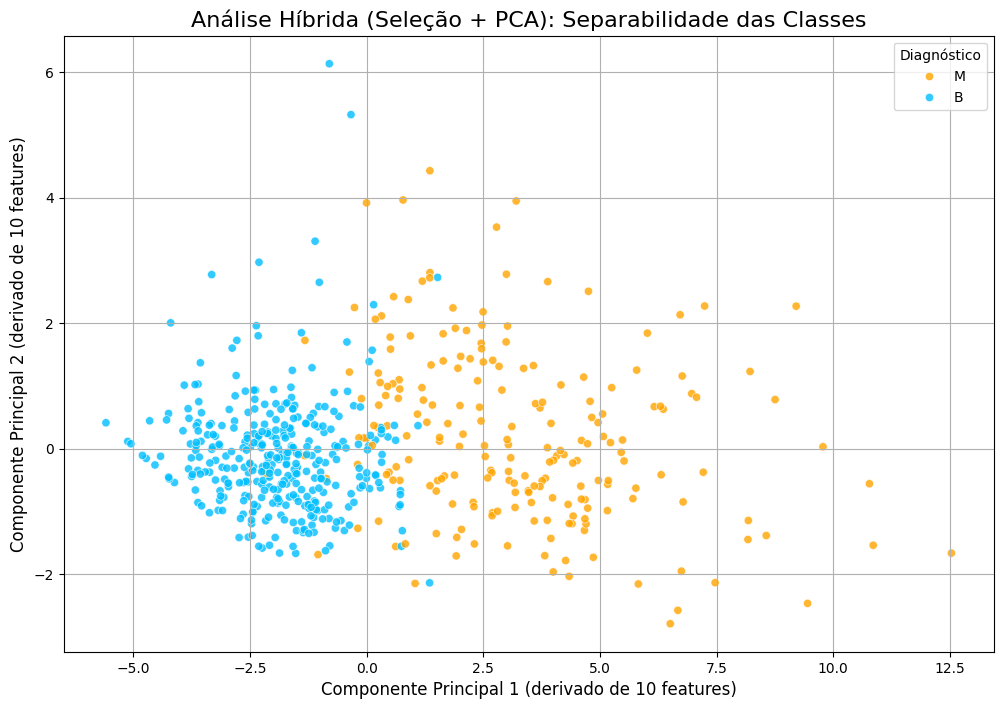

Variância explicada por PC1_hybrid: 84.44%
Variância explicada por PC2_hybrid: 11.03%
Variância total explicada pelos 2 componentes: 95.47%


In [150]:

# 1. (FILTRO) Selecionar as features mais correlacionadas. corr > 0.6
features_selecionadas = [
'concave points_worst',
'perimeter_worst',
'concave points_mean',
'radius_worst',
'perimeter_mean',
'area_worst',
'radius_mean',
'area_mean_log',
'area_mean',
'concavity_mean',
'concavity_worst'
]
X_selected = dt[features_selecionadas]
y = dt['diagnosis'] # A variável alvo permanece a mesma

# 2. Escalonar APENAS as features selecionadas
scaler_hybrid = StandardScaler()
X_selected_scaled = scaler_hybrid.fit_transform(X_selected)

# 3. (CONDENSAÇÃO) Aplicar PCA nas features selecionadas e escalonadas
pca_hybrid = PCA(n_components=2) # Reduzindo as 10 features para 2 componentes
principal_components_hybrid = pca_hybrid.fit_transform(X_selected_scaled)

# 4. Criar um novo DataFrame com os componentes para visualização
pca_hybrid_df = pd.DataFrame(data=principal_components_hybrid, columns=['PC1_hybrid', 'PC2_hybrid'])
pca_hybrid_df = pd.concat([pca_hybrid_df, y.reset_index(drop=True)], axis=1)

# 5. Visualizar a separabilidade das classes com a abordagem híbrida
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1_hybrid', 
    y='PC2_hybrid', 
    hue='diagnosis', 
    data=pca_hybrid_df, 
    palette={'B': 'deepskyblue', 'M': 'orange'},
    alpha=0.8
)

plt.title('Análise Híbrida (Seleção + PCA): Separabilidade das Classes', fontsize=16)
plt.xlabel('Componente Principal 1 (derivado de 10 features)', fontsize=12)
plt.ylabel('Componente Principal 2 (derivado de 10 features)', fontsize=12)
plt.legend(title='Diagnóstico')
plt.grid()
plt.show()

# (Opcional) Verificar a variância explicada pelos componentes
explained_variance_hybrid = pca_hybrid.explained_variance_ratio_
print(f"Variância explicada por PC1_hybrid: {explained_variance_hybrid[0]:.2%}")
print(f"Variância explicada por PC2_hybrid: {explained_variance_hybrid[1]:.2%}")
print(f"Variância total explicada pelos 2 componentes: {np.sum(explained_variance_hybrid):.2%}")

#### Interpretação 

A abordagem anterior, usamos todas as 30 features, nos deu uma boa representação que capturou 64.17% da informação total. Esta nova abordagem híbrida, que primeiro filtramos as 11 features mais preditivas e depois aplicou o PCA, nos deu uma representação mais eficiente, capturando 95.47% da informação contida nessas 10 features. A conclusão principal é que a maior parte da informação preditiva e da variância dos dados está concentrada nessas 10 features selecionadas. As outras 20 features, em grande parte, adicionavam mais "ruído" do que "sinal", diluindo a informação e tornando a tarefa de resumo do PCA menos eficiente.

1. PC1_hybrid (Primeiro Componente Principal)
Essa componente sozinha já explica 84,44% da variância dos dados.
Isso indica que quase toda a informação relevante dessas 11 variáveis está concentrada em uma única direção no espaço dos dados.
Em termos práticos: essas variáveis são altamente redundantes entre si, ou seja, estão fortemente correlacionadas e descrevem o mesmo fenômeno (provavelmente o grau de malignidade).
2. PC2_hybrid (Segundo Componente Principal)
Explica mais 11,03% da variância.
É ortogonal (independente) de PC1 e captura informações complementares que PC1 não conseguiu representar.
3. Variância total explicada (95,47%)
Significa que com apenas 2 componentes principais, você consegue representar quase toda a estrutura dos dados originais.
Isso valida que a seleção das 11 features mais correlacionadas foi muito eficaz.

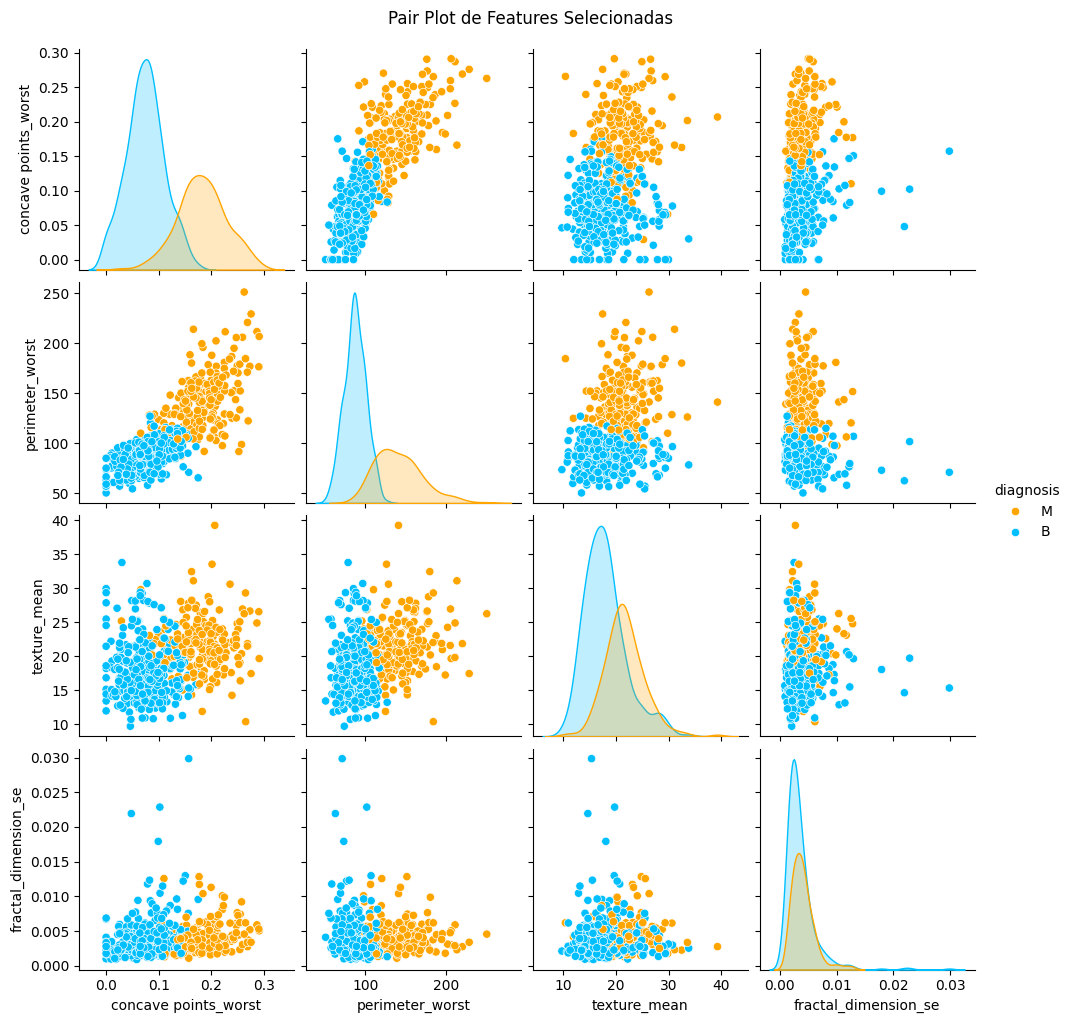

In [151]:
# Selecionar um subconjunto estratégico de features
features_para_pairplot = [
    'diagnosis',
    'concave points_worst', # Preditror nº 1
    'perimeter_worst',    # Preditror nº 2
    'texture_mean',       # Preditror moderado
    'fractal_dimension_se'# Preditror fraco
]

# Criar o pairplot
sns.pairplot(
    dt[features_para_pairplot],
    hue='diagnosis',
    palette={'B': 'deepskyblue', 'M': 'orange'}
)
plt.suptitle('Pair Plot de Features Selecionadas', y=1.02)
plt.show()

1. concave points_worst vs perimeter_worst
- Forte separação entre benignos e malignos.
- Casos malignos tendem a ter valores mais altos em ambas as variáveis.
- Confirma o que vimos no heatmap de correlação: essas duas variáveis têm alta correlação com o diagnóstico.
2. texture_mean
- Distribuição mais sobreposta entre os dois grupos.
- Menor poder discriminativo isoladamente.
- Isso também foi observado nos histogramas e no heatmap (correlação mais fraca).
3. fractal_dimension_se
- Pouca separação entre os grupos.
- A maioria dos pontos se sobrepõe.
- Essa variável tem baixa correlação com o diagnóstico, como já identificado.

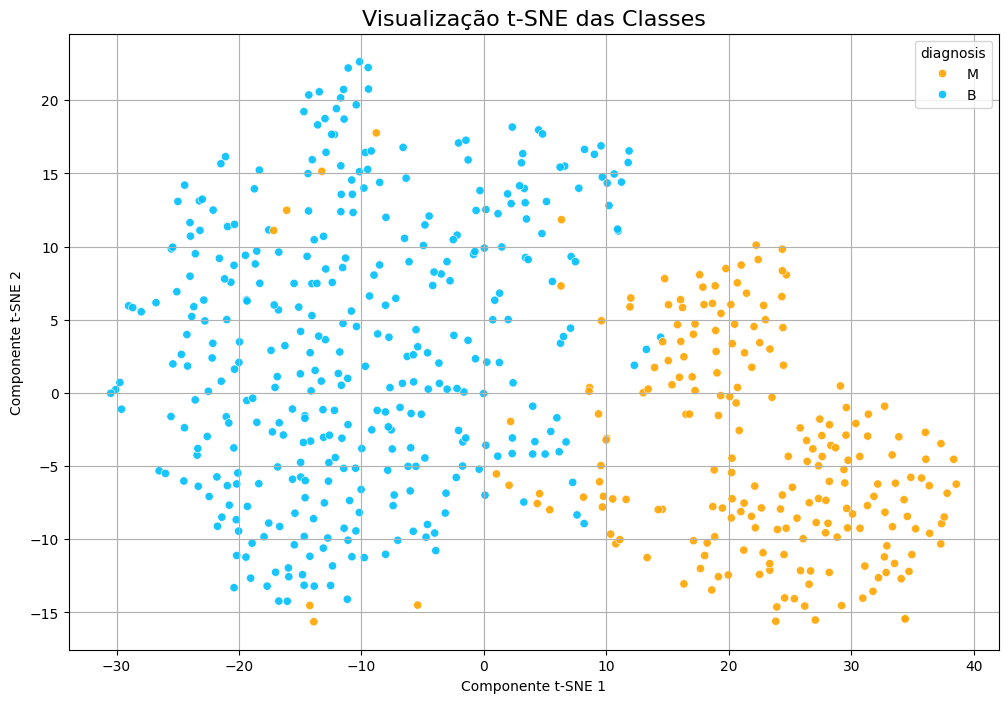

In [152]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Assumindo que 'dt' é seu DataFrame original e 'X' e 'y' já foram separados
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis']

# 1. Escalonar os dados é um pré-requisito
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Instanciar e aplicar o t-SNE
#    'perplexity' é o hiperparâmetro mais importante. Pense nele como o número
#    de vizinhos que cada ponto considera. Valores comuns estão entre 5 e 50.
#    'random_state' é crucial para a reprodutibilidade.
# Instancia o t-SNE sem o argumento n_iter para evitar erro de versão
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_components = tsne.fit_transform(X_scaled)

# 3. Criar um DataFrame para visualização
tsne_df = pd.DataFrame(data=tsne_components, columns=['TSNE1', 'TSNE2'])
tsne_df = pd.concat([tsne_df, y.reset_index(drop=True)], axis=1)

# 4. Visualizar o resultado
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='TSNE1', y='TSNE2', hue='diagnosis', data=tsne_df,
    palette={'B': 'deepskyblue', 'M': 'orange'}, alpha=0.9
)
plt.title('Visualização t-SNE das Classes', fontsize=16)
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid()
plt.show()

#### Interpretação 
Este gráfico é uma visualização não-linear que "mapeia" a vizinhança de cada ponto de dados do espaço original de 30 dimensões para um plano 2D. A interpretação é inequívoca: os tumores Benignos (B) e Malignos (M) formam clusters extraordinariamente bem definidos e densos, com uma separação quase perfeita entre eles. Isso nos dá a maior confiança possível de que existe uma estrutura intrínseca e forte nos dados que diferencia as duas classes.

## Etapa 3: Pré-Processamento e Engenharia de Features

### Tarefa 3.1: Separar as features (X) e a variável alvo (y)

In [153]:
# X recebe todas as colunas menos 'diagnosis'
X = dt.drop(columns=['diagnosis'])

# y recebe apenas a coluna 'diagnosis'
y = dt['diagnosis']

print(f"Features (X) separadas com sucesso! Shape: {X.shape}")
print(f"Variável alvo (y) separada com sucesso! Shape: {y.shape}")

Features (X) separadas com sucesso! Shape: (569, 31)
Variável alvo (y) separada com sucesso! Shape: (569,)


### Tarefa 3.2: Codificar a variável alvo (`diagnosis`) para formato numérico

In [154]:
# Codificar a variável alvo 'diagnosis' para formato numérico
# Mapeia 'M' para 1 (maligno) e 'B' para 0 (benigno) e insere no dataframe

# Codifica a variável alvo 'diagnosis' para formato numérico e armazena em uma nova coluna
dt['diagnosis_num'] = dt['diagnosis'].map({'M': 1, 'B': 0})
print(f"Valores únicos em diagnosis_num: {dt['diagnosis_num'].unique()} (1=Maligno, 0=Benigno)")

# Exibe os primeiros valores codificados para conferência
print(f"Diagnóstico codificado (primeiros valores): {dt['diagnosis_num'].head().tolist()} (1=Maligno, 0=Benigno)")

dt.head()

Valores únicos em diagnosis_num: [1 0] (1=Maligno, 0=Benigno)
Diagnóstico codificado (primeiros valores): [1, 1, 1, 1, 1] (1=Maligno, 0=Benigno)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,area_mean_log,diagnosis_num
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,6.909753,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,7.190676,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,7.093405,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,5.958683,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,7.168580,1


### Tarefa 3.3: Dividir os dados em conjuntos de treino e teste (usando `stratify`)

In [155]:
# Seu código, que está 100% correto
from sklearn.model_selection import train_test_split

# Assumindo que X são as features e y_num é o alvo codificado
y_num = dt['diagnosis_num'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y_num, 
    test_size=0.2,      # 20% dos dados para teste, 80% para treino
    random_state=42,    # Garante que a divisão seja sempre a mesma (reprodutibilidade)
    stratify=y_num      # A instrução para manter as proporções das classes
)

# A validação que prova que a estratificação funcionou
print("Proporção original de classes:")
print(y_num.value_counts(normalize=True).map('{:.2%}'.format))
print("-" * 30)
print("Proporção de classes no conjunto de TREINO:")
print(y_train.value_counts(normalize=True).map('{:.2%}'.format))
print("-" * 30)
print("Proporção de classes no conjunto de TESTE:")
print(y_test.value_counts(normalize=True).map('{:.2%}'.format))

Proporção original de classes:
diagnosis_num
0    62.74%
1    37.26%
Name: proportion, dtype: object
------------------------------
Proporção de classes no conjunto de TREINO:
diagnosis_num
0    62.64%
1    37.36%
Name: proportion, dtype: object
------------------------------
Proporção de classes no conjunto de TESTE:
diagnosis_num
0    63.16%
1    36.84%
Name: proportion, dtype: object


Ao dividir os dados, nosso objetivo é criar um conjunto de treino que seja uma boa representação do problema original e um conjunto de teste que sirva como uma avaliação justa e representativa do desempenho do modelo. Em um dataset desbalanceado, uma divisão puramente aleatória pode, por azar, criar conjuntos não representativos. O parâmetro stratify=y_num resolve isso forçando a divisão a manter a mesma proporção de classes (62.74% B / 37.26% M) tanto no conjunto de treino quanto no de teste.

### Tarefa 3.4: Escalonar as features numéricas (usando `StandardScaler`)

In [156]:
from sklearn.preprocessing import StandardScaler

# Seu código original e correto
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape X_train escalonado: {X_train_scaled.shape}")
print(f"Shape X_test escalonado: {X_test_scaled.shape}\n")

# Verificação (opcional, mas muito instrutiva)
# A média de cada coluna em X_train_scaled deve ser muito próxima de 0.
print(f"Média de uma feature em X_train_scaled: {X_train_scaled[:, 0].mean():.4f}")

# O desvio padrão de cada coluna em X_train_scaled deve ser muito próximo de 1.
print(f"Desvio padrão de uma feature em X_train_scaled: {X_train_scaled[:, 0].std():.4f}")

Shape X_train escalonado: (455, 31)
Shape X_test escalonado: (114, 31)

Média de uma feature em X_train_scaled: -0.0000
Desvio padrão de uma feature em X_train_scaled: 1.0000


### Tarefa 3.5: Redução de Dimensionalidade (PCA para o Modelo 2)


In [157]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Assumindo que 'dt' é seu DataFrame original e limpo
# dt = pd.read_csv('data.csv')
# ...

# --- ETAPA 3 COMPLETA ---

# Tarefa 3.1: Separar as features (X) e a variável alvo (y)
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis']
print("--- 3.1: X e y Separados ---")
print(f"Shape de X: {X.shape}, Shape de y: {y.shape}\n")


# Tarefa 3.2: Codificar a variável alvo ('M' -> 1, 'B' -> 0)
y_num = y.map({'M': 1, 'B': 0})
print("--- 3.2: Alvo (y) Codificado ---")
print(y_num.value_counts(), "\n")


# Tarefa 3.3: Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y_num, test_size=0.2, random_state=42, stratify=y_num
)
print("--- 3.3: Dados Divididos em Treino e Teste ---")
print(f"Shape de X_train: {X_train.shape}, Shape de X_test: {X_test.shape}\n")


# Tarefa 3.4: Escalonar as features numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("--- 3.4: Features Escalonadas ---")
print("Dados prontos para o Modelo 1 (Baseline com 30 features)\n")


# Tarefa 3.5: Redução de Dimensionalidade (PCA para o Modelo 2)
# O PCA é aplicado nos dados JÁ ESCALONADOS
pca = PCA(n_components=10) # Exemplo: reduzindo para 10 componentes
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("--- 3.5: Redução de Dimensionalidade com PCA ---")
print(f"Shape de X_train_pca: {X_train_pca.shape}, Shape de X_test_pca: {X_test_pca.shape}")
print("Dados prontos para o Modelo 2 (Experimento com 10 componentes PCA)\n")

--- 3.1: X e y Separados ---
Shape de X: (569, 32), Shape de y: (569,)

--- 3.2: Alvo (y) Codificado ---
diagnosis
0    357
1    212
Name: count, dtype: int64 

--- 3.3: Dados Divididos em Treino e Teste ---
Shape de X_train: (455, 32), Shape de X_test: (114, 32)

--- 3.4: Features Escalonadas ---
Dados prontos para o Modelo 1 (Baseline com 30 features)

--- 3.5: Redução de Dimensionalidade com PCA ---
Shape de X_train_pca: (455, 10), Shape de X_test_pca: (114, 10)
Dados prontos para o Modelo 2 (Experimento com 10 componentes PCA)



### Tarefa 3.5: Redução de Dimensionalidade (PCA para o Modelo 3 com 10 features)


In [158]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Assumindo que 'dt' é seu DataFrame original e limpo
# ...

# --- ETAPA 3 COMPLETA (VERSÃO REFINADA) ---

# Tarefa 3.1 e 3.2: Separar e Codificar
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# Tarefa 3.3: Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("--- 3.3: Dados Divididos em Treino e Teste ---")
print(f"Shape de X_train: {X_train.shape}, Shape de X_test: {X_test.shape}\n")


# Tarefa 3.4: Escalonar as features (para o Modelo 1 - Baseline)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("--- 3.4: Features Escalonadas ---")
print("Dados prontos para o Modelo 1 (Baseline com 30 features)\n")


# Tarefa 3.5: Abordagem Híbrida (Seleção + PCA) para o Modelo 2
print("--- 3.5: Implementando a Abordagem Híbrida (Seleção + PCA) ---")

# 3.5.1 - (FILTRO) Selecionar as 10 melhores features dos conjuntos de treino e teste
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_train_selected = X_train[features_selecionadas]
X_test_selected = X_test[features_selecionadas]

# 3.5.2 - Escalonar APENAS as features selecionadas
scaler_hybrid = StandardScaler()
X_train_selected_scaled = scaler_hybrid.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_hybrid.transform(X_test_selected)

# 3.5.3 - (CONDENSAÇÃO) Aplicar PCA nos dados selecionados e escalonados
# Usaremos o nome 'pca_hybrid' como você sugeriu
pca_hybrid = PCA(n_components=2) 
X_train_pca_hybrid = pca_hybrid.fit_transform(X_train_selected_scaled)
X_test_pca_hybrid = pca_hybrid.transform(X_test_selected_scaled)

print(f"Shape de X_train_pca_hybrid: {X_train_pca_hybrid.shape}")
print("Dados prontos para o Modelo 2 (Experimento Híbrido com 2 componentes PCA)\n")

--- 3.3: Dados Divididos em Treino e Teste ---
Shape de X_train: (455, 32), Shape de X_test: (114, 32)

--- 3.4: Features Escalonadas ---
Dados prontos para o Modelo 1 (Baseline com 30 features)

--- 3.5: Implementando a Abordagem Híbrida (Seleção + PCA) ---
Shape de X_train_pca_hybrid: (455, 2)
Dados prontos para o Modelo 2 (Experimento Híbrido com 2 componentes PCA)



## Etapa 4: Modelagem e Treinamento, Avaliação do Modelo e Análise de Resultados - Regressão Logística
### Tarefa 4.1: Instanciar o modelo de baseline 
### Tarefa 4.2: Treinar o modelo com os dados de treino escalonados
### Tarefa 4.3: Realizar previsões com o conjunto de teste
### Tarefa 4.4: Calcular e analisar as métricas de classificação (Acurácia, Precisão, Recall, F1-Score, AUC)
### Tarefa 4.5: Gerar e visualizar a Matriz de Confusão

Dataset carregado e limpo com sucesso.
--- Pipeline para Regressão Logística Definido ---
Treinando o pipeline...


Treinamento concluído.

--- Avaliação no Conjunto de Teste ---
Relatório de Classificação:
              precision    recall  f1-score   support

 Benigno (B)       0.96      0.99      0.97        72
 Maligno (M)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Matriz de Confusão:


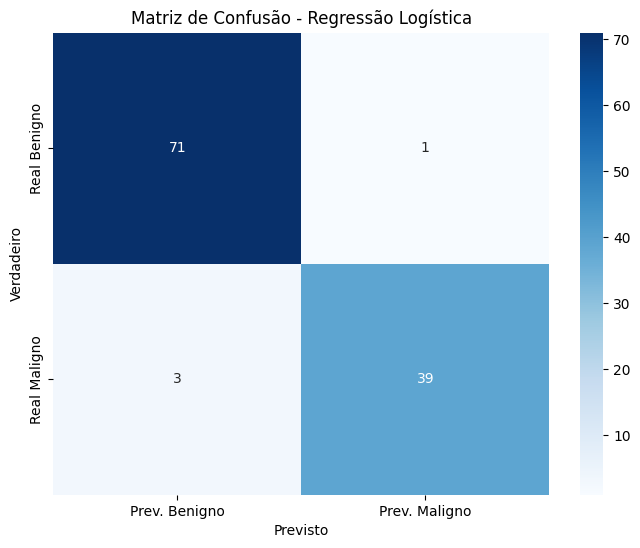

In [159]:
# --- Bloco de Código Focado: Pipeline para Regressão Logística ---


import os
try:
    dt = pd.read_csv('breast_cancer.csv')
    # Limpeza preliminar
    if 'id' in dt.columns:
        dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns:
        dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset carregado e limpo com sucesso.")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado. Certifique-se de que o arquivo está no diretório correto.")
    os.exit(1)

# 2. Carregamento e preparação dos dados (Etapas 1 a 3.3)

X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Definição do Pipeline específico para a Regressão Logística
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])
print("--- Pipeline para Regressão Logística Definido ---")

# 4. Treinamento do Pipeline
print("Treinando o pipeline...")
pipeline_lr.fit(X_train, y_train)
print("Treinamento concluído.\n")

# 5. Avaliação do Pipeline
print("--- Avaliação no Conjunto de Teste ---")
# Fazer previsões nos dados de teste
y_pred_lr = pipeline_lr.predict(X_test)

# Gerar e imprimir o Relatório de Classificação
# Este relatório é a nossa principal ferramenta de avaliação numérica
print("Relatório de Classificação:")
reportLogisticRegression= classification_report(y_test, y_pred_lr, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportLogisticRegression)

# Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão:")
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretação**

O modelo de Regressão Logística obteve um desempenho geral excelente, com uma acurácia de 96%. No entanto, a análise detalhada da Matriz de Confusão e do Relatório de Classificação revela que o modelo cometeu 3 erros críticos (Falsos Negativos), classificando tumores malignos como benignos. Embora a performance seja alta, esses erros são o principal ponto de atenção e o foco para melhorias futuras, dada a natureza médica do problema. O modelo de Regressão Logística alcançou uma performance geral muito alta, com 96% de acurácia, e demonstrou uma grande capacidade de identificar corretamente os casos benignos.
No entanto, a análise da matriz de confusão revelou o ponto crítico deste projeto: o modelo falhou em identificar 3 dos 42 casos malignos, resultando em um Recall de 93% para a classe maligna. Embora alto, este é o nosso principal ponto de melhoria.

Pelo Relatório de Classificação podemos dizer: 

- Acurácia (accuracy): 96%
    - O que é: (VP + VN) / Total = (39 + 71) / 114 = 0.96
    - De todos os diagnósticos, o modelo acertou 96%. É um bom número geral, mas esconde os erros críticos.
- Precisão (precision)
    - Maligno (M): 97% (VP / (VP + FP) = 39 / (39 + 1) = 0.975). Das vezes que o modelo disse "Maligno", ele estava certo em 97% dos casos.
    - Benigno (B): 96% (VN / (VN + FN) = 71 / (71 + 3) = 0.959). Das vezes que o modelo disse "Benigno", ele estava certo em 96% dos casos.
    - A precisão para a classe maligna é muito alta, o que é bom (poucos alarmes falsos).
- Recall (Sensibilidade) - A MÉTRICA MAIS IMPORTANTE AQUI!
    - Maligno (M): 93% (VP / (VP + FN) = 39 / (39 + 3) = 0.928). De todos os tumores que eram realmente Malignos, o modelo conseguiu identificar 93% deles.
     -Benigno (B): 99% (VN / (VN + FP) = 71 / (71 + 1) = 0.986). De todos os casos que eram realmente Benignos, o modelo identificou 99%.
    - O Recall de 93% para a classe Maligna é o nosso principal indicador de desempenho. Significa que 7% dos tumores malignos (os 3 casos de Falsos Negativos) não foram detectados. Nosso objetivo nos próximos modelos será aumentar este número, idealmente para o mais próximo possível de 100%.
- F1-Score:
    - O que é: A média harmônica entre precisão e recall. É uma ótima métrica de equilíbrio.
    - Os valores de 95% (Maligno) e 97% (Benigno) mostram que o modelo tem um excelente equilíbrio geral entre não criar alarmes falsos e não perder casos positivos.


Pelo Grafico da Confusão podemos dizer:

- Verdadeiros Positivos (VP): 39
    - O que é: O modelo previu corretamente 39 tumores como Malignos.
    - Estes são os "acertos" mais importantes. O modelo foi bem em identificar a maioria dos casos de câncer.
- Verdadeiros Negativos (VN): 71
    - O que é: O modelo previu corretamente 71 casos como Benignos.
    - O modelo é excelente em dar "alta" a pacientes saudáveis, evitando preocupações desnecessárias.
-   Falsos Positivos (FP) - Erro Tipo I: 1
    - O que é: O modelo previu 1 caso como Maligno, mas na verdade era Benigno.
    - Este é um "alarme falso". Causa estresse ao paciente, que precisaria de mais exames para confirmar, mas é um erro menos grave do que o oposto.
- Falsos Negativos (FN) - Erro Tipo II: 3
    - O que é: O modelo previu 3 casos como Benignos, mas na verdade eram Malignos.
    - Este é o erro mais perigoso e crítico. Estes 3 pacientes seriam mandados para casa com um diagnóstico incorreto de que estão bem, atrasando o tratamento. Minimizar este número é o nosso objetivo principal.

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv' carregado e limpo com sucesso.

--- Etapa de Pré-processamento ---
Features selecionadas para o modelo: 10 colunas.
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline ---
Pipeline Híbrido (Scaler -> PCA -> LogisticRegression) definido.
Treinando o pipeline híbrido com os dados de treino...
Treinamento concluído.

--- Etapa de Avaliação no Conjunto de Teste ---
Relatório de Classificação:
              precision    recall  f1-score   support

 Benigno (B)       0.95      1.00      0.97        72
 Maligno (M)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

Matriz de Confusão:


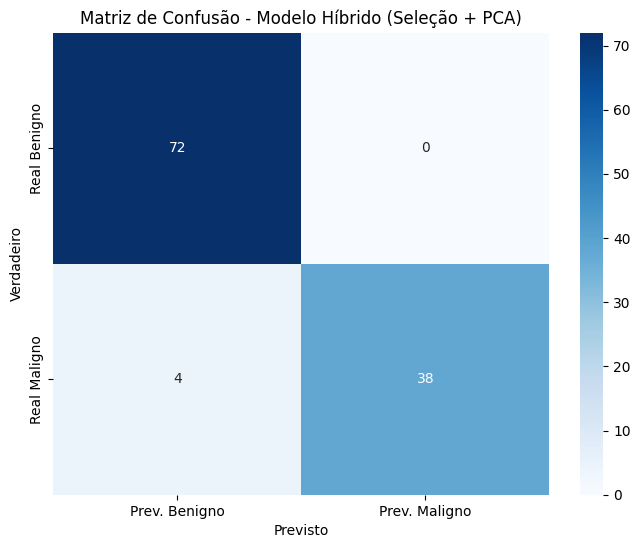

In [160]:
# --- Bloco de Código Completo: Pipeline Híbrido (Seleção + PCA) de Ponta a Ponta ---


# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    # Carregar o dataset a partir do arquivo 'breast_cancer.csv'
    dt = pd.read_csv('breast_cancer.csv')
    
    # Limpeza preliminar de colunas irrelevantes
    if 'id' in dt.columns:
        dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns:
        dt = dt.drop(columns=['Unnamed: 32'])
    
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado. ")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processamento ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0}) # Maligno=1, Benigno=0

# 3.3: Definir a lista das features selecionadas com base na EDA
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
# Filtrar o DataFrame X para conter apenas as features selecionadas
X_selected = X[features_selecionadas]

print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados em conjuntos de treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 4: Definição e Treinamento do Pipeline Híbrido ---
print("--- Etapa de Modelagem com Pipeline ---")

# 4.1: Definição do Pipeline Híbrido
pipeline_hybrid_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])
print("Pipeline Híbrido (Scaler -> PCA -> LogisticRegression) definido.")

# 4.2: Treinamento do Pipeline
print("Treinando o pipeline híbrido com os dados de treino...")
pipeline_hybrid_pca.fit(X_train, y_train)
print("Treinamento concluído.\n")


# --- ETAPA 5: Avaliação do Pipeline Híbrido ---
print("--- Etapa de Avaliação no Conjunto de Teste ---")

# 5.1: Fazer previsões usando o pipeline treinado
y_pred_hybrid = pipeline_hybrid_pca.predict(X_test)

# 5.2: Gerar e imprimir o Relatório de Classificação
print("Relatório de Classificação:")
reportPCASelecaoLogisticRegression = classification_report(y_test, y_pred_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaoLogisticRegression)

# 5.3: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão:")
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Modelo Híbrido (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

Na pepilene acima decimos utilizar um caminho Híbrido (Seleção + PCA) e alcançou a mesma acurácia geral de 96% que o modelo utilizando todas as 30 features. No entanto, ele exibe um perfil de comportamento muito diferente: tornou-se um modelo extremamente "cauteloso", alcançando uma Precisão perfeita (100%) para a classe Maligna, o que significa que ele não gerou nenhum alarme falso. O custo dessa cautela, no entanto, foi uma ligeira queda no Recall (90%), resultando em 4 Falsos Negativos — um erro crítico a mais que o modelo baseline. Para o contexto médico, o modelo baseline, apesar de mais complexo, é atualmente superior por ser mais sensível.

Interpretando o Relatório de Classificação
- Acurácia (accuracy): 96%
    - (38 + 72) / 114 = 0.96. A performance geral é a mesma do baseline, o que é interessante, mas enganoso se olhado isoladamente.
- Precisão (precision)
    - Maligno (M): 1.00 (100%) (VP / (VP + FP) = 38 / (38 + 0) = 1.0).
    - Interpretação: Este é o ponto forte do modelo. Quando ele diz que um tumor é Maligno, ele está 100% certo. Ele tem total confiança em suas previsões positivas.
- Recall (Sensibilidade)
    - Maligno (M): 0.90 (90%) (VP / (VP + FN) = 38 / (38 + 4) = 0.904).
    - Interpretação: De todos os tumores que eram realmente Malignos no conjunto de teste, o modelo híbrido conseguiu encontrar 90% deles.
    - Comparação: O modelo baseline alcançou um Recall de 93%. Portanto, o baseline foi mais sensível e melhor em sua tarefa principal de detectar o câncer.

Interpretando Matriz de Confusão:
- Verdadeiros Positivos (VP): 38
    - O modelo identificou corretamente 38 dos 42 tumores malignos.
    - Verdadeiros Negativos (VN): 72
    - O modelo identificou corretamente todos os 72 casos benignos. Desempenho perfeito aqui.
- Falsos Positivos (FP) - Erro Tipo I: 0
    - Este é o resultado mais notável. O modelo não cometeu nenhum erro ao classificar um tumor benigno como maligno. Não houve alarmes falsos.
- Falsos Negativos (FN) - Erro Tipo II: 4
    - Este é o resultado mais crítico. O modelo classificou 4 tumores malignos como benignos.
    - Comparação: O modelo baseline (com 30 features) cometeu 3 Falsos Negativos. Portanto, o modelo híbrido, apesar de sua elegância, cometeu um erro perigoso a mais.

O Modelo Baseline ao usar todas as 30 features, é mais "sensível e abrangente". Ele utiliza um leque maior de informações, incluindo o "ruído" e as nuances das features menos correlacionadas. Isso o torna um pouco menos confiante em suas previsões positivas (Precisão de 97%), cometendo um alarme falso. No entanto, essa mesma abrangência lhe permite ser mais sensível, capturando um caso maligno a mais que o modelo híbrido (Recall de 93%).

O Modelo Híbrido, por outro lado,  se transformou em um especialista "cauteloso e conservador". Ao focar apenas no sinal mais forte das 10 melhores features, ele construiu um modelo de altíssima confiança: ele só classifica um tumor como maligno se tiver certeza absoluta, resultando em uma precisão perfeita de 100%. O custo dessa certeza, no entanto, é uma sensibilidade ligeiramente menor (Recall de 90%), fazendo com que ele ignore alguns casos mais ambíguos, resultando em um Falso Negativo a mais.


## Etapa 5: Modelagem e Treinamento, Avaliação do Modelo e Análise de Resultados -  K-Nearest Neighbors (KNN)
### Tarefa 5.1: Instanciar o modelo de baseline 
### Tarefa 5.2: Treinar o modelo com os dados de treino escalonados
### Tarefa 5.3: Realizar previsões com o conjunto de teste
### Tarefa 5.4: Calcular e analisar as métricas de classificação (Acurácia, Precisão, Recall, F1-Score, AUC)
### Tarefa 5.5: Gerar e visualizar a Matriz de Confusão

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv' carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline para KNN ---
Pipeline para KNN (k=5) Definido.
Treinando o pipeline KNN com os dados de treino...
Treinamento concluído.

--- Etapa de Avaliação do KNN no Conjunto de Teste ---
Relatório de Classificação - KNN:
              precision    recall  f1-score   support

 Benigno (B)       0.95      0.99      0.97        72
 Maligno (M)       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

AUC (Area Under the Curve): 0.9823

Matriz de Confusão - KNN:


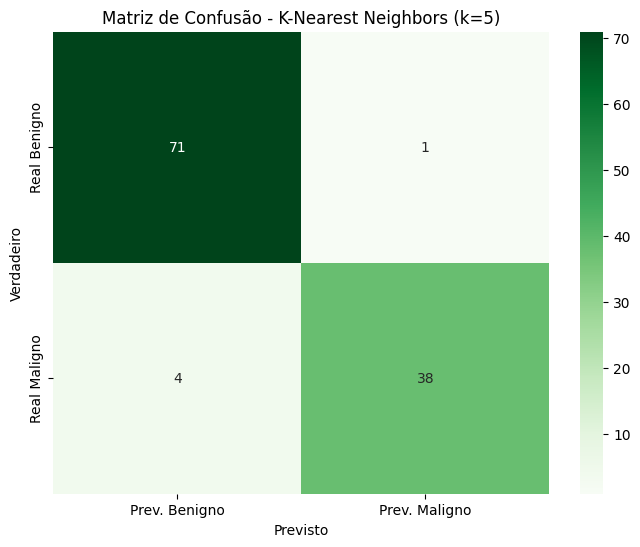

In [161]:
# --- Bloco de Código Completo: Pipeline para K-Nearest Neighbors (KNN) ---

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    # Carregar o dataset a partir do arquivo 'breast_cancer.csv'
    dt = pd.read_csv('breast_cancer.csv')
    
    # Limpeza preliminar de colunas irrelevantes
    if 'id' in dt.columns:
        dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns:
        dt = dt.drop(columns=['Unnamed: 32'])
    
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0}) # Maligno=1, Benigno=0

# 3.3: Dividir os dados em conjuntos de treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# ---  Modelagem, Treinamento e Avaliação com KNN ---
print("--- Etapa de Modelagem com Pipeline para KNN ---")

# Instanciar o modelo KNN dentro de um Pipeline
# O valor de k (n_neighbors) é um hiperparâmetro. k=5 é um ponto de partida comum.
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])
print("Pipeline para KNN (k=5) Definido.")

# Tarefa 5.2: Treinamento do Pipeline
print("Treinando o pipeline KNN com os dados de treino...")
pipeline_knn.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Tarefa 5.3: Realizar previsões com o conjunto de teste
print("--- Etapa de Avaliação do KNN no Conjunto de Teste ---")
y_pred_knn = pipeline_knn.predict(X_test)
y_proba_knn = pipeline_knn.predict_proba(X_test)[:, 1] # Para AUC

# Tarefa 5.4: Calcular e analisar as métricas de classificação
print("Relatório de Classificação - KNN:")
reportKNeighborsClassifier = classification_report(y_test, y_pred_knn, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportKNeighborsClassifier)

# Calcular e exibir a AUC
auc_knn = roc_auc_score(y_test, y_proba_knn)
print(f"AUC (Area Under the Curve): {auc_knn:.4f}\n")

# Tarefa 5.5: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - KNN:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - K-Nearest Neighbors (k=5)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretação**

O modelo KNN (com k=5) alcançou uma performance geral muito alta, com 96% de acurácia, similar à Regressão Logística. No entanto, a análise detalhada revela que ele tem um perfil de erro diferente. Ele cometeu 4 Falsos Negativos, resultando em um Recall de 90% para a classe Maligna, um desempenho ligeiramente inferior ao da Regressão Logística neste quesito crítico. A altíssima AUC de 0.9823 indica que o modelo tem um excelente poder discriminatório geral, mas o ponto de corte padrão (baseado em 5 vizinhos) não otimizou para a sensibilidade. 

Análise da Matriz de Confusão do KNN
- Verdadeiros Positivos (VP): 38
    - O modelo identificou corretamente 38 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 71
    - O modelo identificou corretamente 71 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 1
    - O modelo gerou apenas 1 alarme falso.
- Falsos Negativos (FN) - Erro Tipo II: 4
    - Este é o ponto crucial. O modelo deixou de diagnosticar 4 tumores malignos.

Análise do Relatório de Classificação do KNN
- Acurácia (accuracy): 96%
    - Um desempenho geral muito forte.
- Precisão (precision) - Maligno: 97%
    - 38 / (38 + 1) = 0.974. Das vezes que o KNN disse "Maligno", ele estava certo em 97% das vezes. Excelente precisão.
- Recall (Sensibilidade) - Maligno: 90%
    - 38 / (38 + 4) = 0.904. De todos os tumores que eram realmente Malignos, o KNN conseguiu identificar 90%.
- AUC (Area Under the Curve): 0.9823
    - Este é um valor excelente. Ele nos diz que o poder de discriminação inerente do modelo é muito alto. A probabilidade de o modelo atribuir uma pontuação de risco maior a um caso maligno aleatório do que a um benigno aleatório é de 98.23%.

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv' carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Features selecionadas para o modelo: 10 colunas.
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline Híbrido para KNN ---
Pipeline Híbrido para KNN (k=5) Definido.
Treinando o pipeline KNN híbrido...
Treinamento concluído.

--- Etapa de Avaliação do KNN Híbrido no Conjunto de Teste ---
Relatório de Classificação - KNN Híbrido:
              precision    recall  f1-score   support

 Benigno (B)       0.93      0.99      0.96        72
 Maligno (M)       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

AUC (Area Under the Curve): 0.9936

Matriz de Confusão - KNN Híbrido:


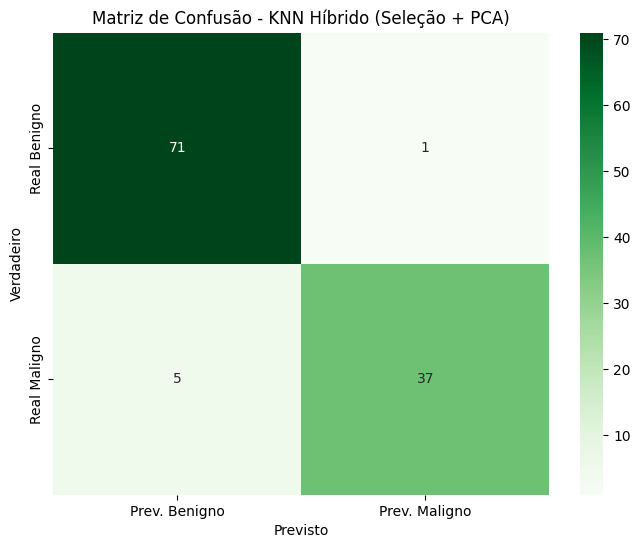

In [162]:
# --- Bloco de Código Completo: Pipeline Híbrido para K-Nearest Neighbors (KNN) ---
 

print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    # Carregar o dataset a partir do arquivo 'breast_cancer.csv'
    dt = pd.read_csv('breast_cancer.csv')
    
    # Limpeza preliminar de colunas irrelevantes
    if 'id' in dt.columns:
        dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns:
        dt = dt.drop(columns=['Unnamed: 32'])
    
    print("Dataset 'breast_cancer.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv' não encontrado. ")
    os.exit(1)

# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 4 e 5: Modelagem Híbrida, Treinamento e Avaliação com KNN ---
print("--- Etapa de Modelagem com Pipeline Híbrido para KNN ---")

# Tarefa 5.1: Instanciar o modelo KNN dentro de um Pipeline Híbrido
pipeline_knn_hybrid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])
print("Pipeline Híbrido para KNN (k=5) Definido.")

# Tarefa 5.2: Treinamento do Pipeline
print("Treinando o pipeline KNN híbrido...")
pipeline_knn_hybrid.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Tarefa 5.3: Realizar previsões com o conjunto de teste
print("--- Etapa de Avaliação do KNN Híbrido no Conjunto de Teste ---")
y_pred_knn_hybrid = pipeline_knn_hybrid.predict(X_test)
y_proba_knn_hybrid = pipeline_knn_hybrid.predict_proba(X_test)[:, 1]

# Tarefa 5.4: Calcular e analisar as métricas de classificação
print("Relatório de Classificação - KNN Híbrido:")
reportPCASelecaoKNeighborsClassifier = classification_report(y_test, y_pred_knn_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaoKNeighborsClassifier)

auc_knn_hybrid = roc_auc_score(y_test, y_proba_knn_hybrid)
print(f"AUC (Area Under the Curve): {auc_knn_hybrid:.4f}\n")

# Tarefa 5.5: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - KNN Híbrido:")
cm_knn_hybrid = confusion_matrix(y_test, y_pred_knn_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn_hybrid, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - KNN Híbrido (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretacao**

O modelo KNN Híbrido (k=5) alcançou uma performance geral de 95% de acurácia. No entanto, a análise detalhada revela que esta abordagem de engenharia de features, quando combinada com o KNN, resultou no pior desempenho em nossa métrica mais crítica: o Recall para a classe Maligna caiu para 88%, e o número de Falsos Negativos aumentou para 5. Curiosamente, a métrica AUC foi a mais alta de todos os modelos testados, indicando um poder de discriminação latente excepcional, mas que não se traduziu em maior sensibilidade na prática com a configuração atual.


Análise da Matriz de Confusão do KNN Híbrido
- Verdadeiros Positivos (VP): 37
    - O modelo identificou corretamente 37 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 71
    - O modelo identificou corretamente 71 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 1
    - O modelo gerou apenas 1 alarme falso, um resultado excelente em precisão.
- Falsos Negativos (FN) - Erro Tipo II: 5
    - Este é o resultado mais preocupante. O modelo falhou em diagnosticar 5 tumores malignos. Este é o pior resultado entre todos os modelos que testamos.

Análise do Relatório de Classificação do KNN Híbrido
- Acurácia (accuracy): 95%
    - Ligeiramente inferior à dos outros modelos (96%).
- Precisão (precision) - Maligno: 97%
    - 37 / (37 + 1) = 0.97. Excelente precisão, similar ao KNN com 30 features.
- Recall (Sensibilidade) - Maligno: 88%
    - 37 / (37 + 5) = 0.88. Este é o ponto mais fraco do modelo, representando uma queda significativa em comparação com a Regressão Logística.
- AUC (Area Under the Curve): 0.9936
    - Este é um resultado fascinante e paradoxal. A AUC deste modelo é a mais alta de todas. Isso significa que os 5 componentes PCA criados a partir das 10 features selecionadas criam um espaço onde as classes são, em teoria, extremamente bem separadas. O poder de discriminação geral do modelo é quase perfeito. O problema não está nas features, mas na forma como o algoritmo KNN (com k=5) traça a "fronteira" de decisão nesse espaço, que acaba sendo muito conservadora e deixando 5 casos malignos do lado errado.

## Etapa 6: Pipeline com modelagem e treinamento, avaliação do modelo e análise de resultados - Support Vector Classifier (SVC)
### Tarefa 6.1: instanciar o modelo de baseline 
### Tarefa 6.2: treinar o modelo com os dados de treino escalonados
### Tarefa 6.3: realizar previsões com o conjunto de teste
### Tarefa 6.4: calcular e analisar as métricas de classificação (acurácia, precisão, recall, f1-score, auc)
### Tarefa 6.6: gerar e visualizar a matriz de confusão

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'data.csv' carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Treinando e Avaliando: SVM (Linear) ---
Relatório de Classificação (Linear):
              precision    recall  f1-score   support

 Benigno (B)       0.95      1.00      0.97        72
 Maligno (M)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

AUC (Area Under the Curve): 0.9914

Matriz de Confusão - SVM (Linear):


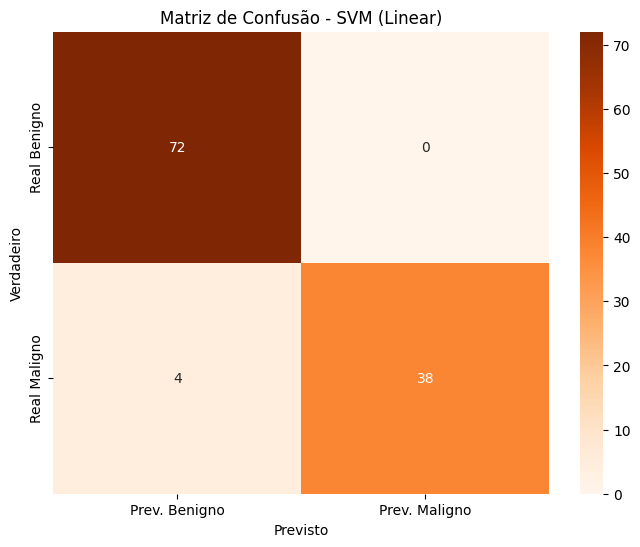

------------------------------------------------------------
--- Treinando e Avaliando: SVM (RBF) ---
Relatório de Classificação (RBF):
              precision    recall  f1-score   support

 Benigno (B)       0.99      0.99      0.99        72
 Maligno (M)       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

AUC (Area Under the Curve): 0.9954

Matriz de Confusão - SVM (RBF):


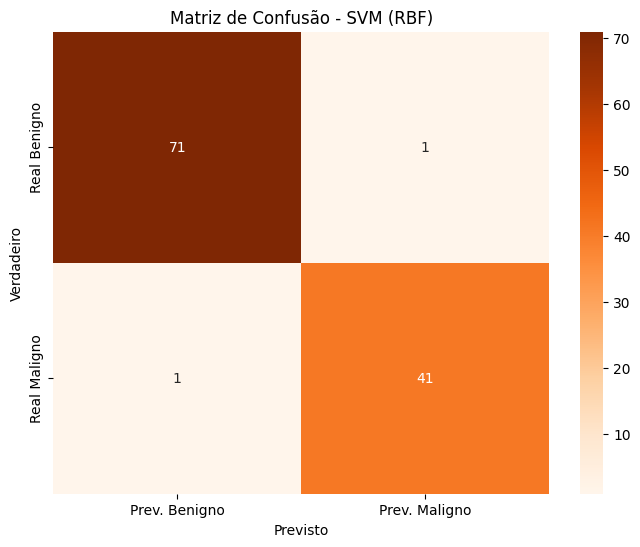

------------------------------------------------------------


In [163]:
# --- Bloco de Código Completo: Pipelines para Support Vector Classifier (SVC) ---

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'data.csv' carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'data.csv' não encontrado. ")
    os.exit(1)

# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")

# --- ETAPA 6: Modelagem, Treinamento e Avaliação com SVM ---

# 6.1: Definir os Pipelines para SVC Linear e SVC RBF
pipeline_svc_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='linear', random_state=42, probability=True))
])

pipeline_svc_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', random_state=42, probability=True, class_weight='balanced'))
])

# Treinamento e avaliação para SVM Linear
print("--- Treinando e Avaliando: SVM (Linear) ---")
pipeline_svc_linear.fit(X_train, y_train)
y_pred_linear = pipeline_svc_linear.predict(X_test)
y_proba_linear = pipeline_svc_linear.predict_proba(X_test)[:, 1]
report_svc_linear = classification_report(y_test, y_pred_linear, target_names=['Benigno (B)', 'Maligno (M)'])
auc_linear = roc_auc_score(y_test, y_proba_linear)
print("Relatório de Classificação (Linear):")
print(report_svc_linear)
print(f"AUC (Area Under the Curve): {auc_linear:.4f}\n")
print(f"Matriz de Confusão - SVM (Linear):")
cm_linear = confusion_matrix(y_test, y_pred_linear)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (Linear)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
print("-" * 60)

# Treinamento e avaliação para SVM RBF
print("--- Treinando e Avaliando: SVM (RBF) ---")
pipeline_svc_rbf.fit(X_train, y_train)
y_pred_rbf = pipeline_svc_rbf.predict(X_test)
y_proba_rbf = pipeline_svc_rbf.predict_proba(X_test)[:, 1]
report_svc_rbf = classification_report(y_test, y_pred_rbf, target_names=['Benigno (B)', 'Maligno (M)'])
auc_rbf = roc_auc_score(y_test, y_proba_rbf)
print("Relatório de Classificação (RBF):")
print(report_svc_rbf)
print(f"AUC (Area Under the Curve): {auc_rbf:.4f}\n")
print(f"Matriz de Confusão - SVM (RBF):")
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (RBF)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
print("-" * 60)

#### SVM Linear

O modelo SVM com kernel linear apresentou um desempenho geral muito alto, com 96% de acurácia, e demonstrou um comportamento notável: alcançou precisão perfeita (100%) para a classe Maligna, não gerando nenhum alarme falso. No entanto, esse perfil "cauteloso" resultou em um Recall de 90% para a mesma classe, com 4 Falsos Negativos. O desempenho é estatisticamente quase idêntico ao do modelo híbrido com Regressão Logística, mostrando que, para este problema, a fronteira de decisão ideal encontrada por modelos lineares tende a ser muito similar.

Análise da Matriz de Confusão do SVM Linear
- Verdadeiros Positivos (VP): 38
    - O modelo identificou corretamente 38 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 72
    - O modelo identificou corretamente todos os 72 casos benignos. Desempenho perfeito para a classe negativa.
- Falsos Positivos (FP) - Erro Tipo I: 0
    - Resultado notável: O modelo não cometeu nenhum erro ao classificar um tumor benigno como maligno. Não houve alarmes falsos.
- Falsos Negativos (FN) - Erro Tipo II: 4
    - Ponto Crítico: O modelo falhou em diagnosticar 4 tumores malignos, classificando-os como benignos.

Análise do Relatório de Classificação do SVM Linear
- Acurácia (accuracy): 96%
    - (38 + 72) / 114 = 0.96. Um desempenho geral excelente.
- Precisão (precision) - Maligno: 1.00 (100%)
    - 38 / (38 + 0) = 1.0. Quando este modelo diz "Maligno", podemos confiar 100% nessa previsão. É um modelo de altíssima confiança nas suas previsões positivas.
- Recall (Sensibilidade) - Maligno: 0.90 (90%)
    - 38 / (38 + 4) = 0.905. De todos os tumores que eram realmente Malignos, o SVM Linear conseguiu identificar 90%.
- AUC (Area Under the Curve): 0.9914
    - Um valor excelente, indicando um poder de discriminação geral muito alto, quase no mesmo nível da Regressão Logística com 30 features.

#### SVR (regressão)

O modelo SVM com kernel RBF alcançou um desempenho quase perfeito, com uma acurácia impressionante de 98% e métricas de precisão, recall e f1-score extremamente altas para ambas as classes. Mais importante, ele conseguiu reduzir o número de Falsos Negativos para apenas 1, superando todos os modelos anteriores na nossa métrica mais crítica. A capacidade do kernel RBF de criar uma fronteira de decisão não-linear foi a chave para capturar a complexa separação entre as classes de forma mais eficaz, validando as hipóteses que levantamos durante a EDA com o t-SNE.

Análise da Matriz de Confusão do SVM (RBF)
- Verdadeiros Positivos (VP): 41
    - O modelo identificou corretamente 41 dos 42 tumores malignos. Um resultado excelente.
- Verdadeiros Negativos (VN): 71
    - O modelo identificou corretamente 71 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 1
    - O modelo gerou apenas 1 alarme falso. Um resultado de altíssima precisão.
- Falsos Negativos (FN) - Erro Tipo II: 1
    - Este é o resultado mais importante. O modelo falhou em diagnosticar apenas 1 tumor maligno. Este é o menor número de erros críticos que vimos até agora.

Análise do Relatório de Classificação do SVM (RBF)
- Acurácia (accuracy): 98%
    - (41 + 71) / 114 = 0.982. Uma melhoria clara em relação aos 96% dos modelos lineares.
- Precisão (precision) - Maligno: 98%
    - 41 / (41 + 1) = 0.976. Quase perfeita. Quando o modelo diz "Maligno", ele está certo em 98% das vezes.
- Recall (Sensibilidade) - Maligno: 98%
    - 41 / (41 + 1) = 0.976. De todos os tumores que eram realmente Malignos, o SVM com RBF conseguiu identificar 98% deles.
- AUC (Area Under the Curve): 0.9954
    - Um valor altíssimo, muito próximo de 1.0, indicando um poder de discriminação quase perfeito.

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Features selecionadas para o modelo: 10 colunas.
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Treinando e Avaliando: SVM (Linear) ---
Relatório de Classificação (Linear):
              precision    recall  f1-score   support

 Benigno (B)       0.96      1.00      0.98        72
 Maligno (M)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

AUC (Area Under the Curve): 0.9987

Matriz de Confusão - SVM (Linear):


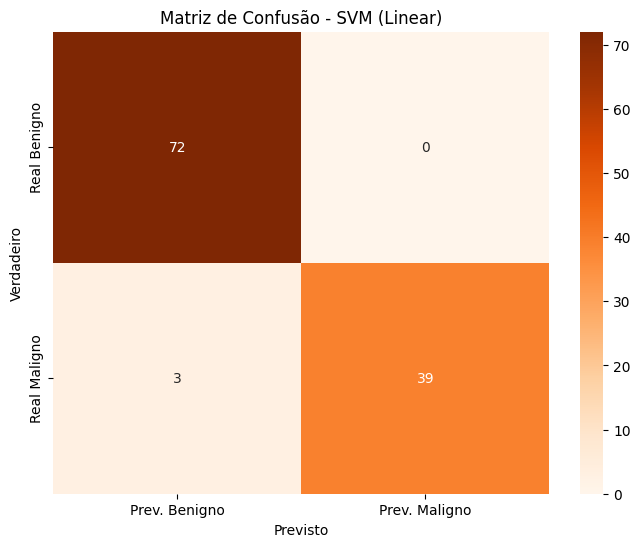

------------------------------------------------------------
--- Treinando e Avaliando: SVM (RBF) ---
Relatório de Classificação (RBF):
              precision    recall  f1-score   support

 Benigno (B)       0.95      1.00      0.97        72
 Maligno (M)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

AUC (Area Under the Curve): 0.9980

Matriz de Confusão - SVM (RBF):


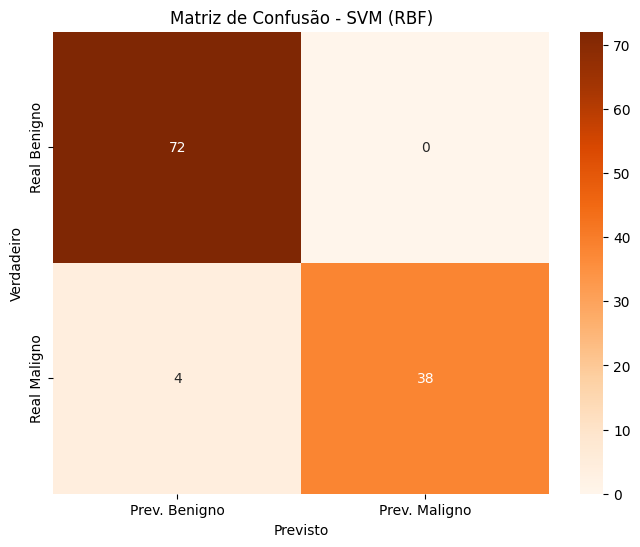

------------------------------------------------------------


In [164]:
# --- Bloco de Código Completo: Pipeline Híbrido para SVM (RBF) ---
 

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado .")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")

# Treinamento e avaliação para SVM Linear
print("--- Treinando e Avaliando: SVM (Linear) ---")
pipeline_svc_linear.fit(X_train, y_train)
y_pred_linear = pipeline_svc_linear.predict(X_test)
y_proba_linear = pipeline_svc_linear.predict_proba(X_test)[:, 1]
report_pcaSeleca_svc_linear = classification_report(y_test, y_pred_linear, target_names=['Benigno (B)', 'Maligno (M)'])
auc_linear = roc_auc_score(y_test, y_proba_linear)
print("Relatório de Classificação (Linear):")
print(report_pcaSeleca_svc_linear)
print(f"AUC (Area Under the Curve): {auc_linear:.4f}\n")
print("Matriz de Confusão - SVM (Linear):")
cm_linear = confusion_matrix(y_test, y_pred_linear)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (Linear)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
print("-" * 60)

# Treinamento e avaliação para SVM RBF
print("--- Treinando e Avaliando: SVM (RBF) ---")
pipeline_svc_rbf.fit(X_train, y_train)
y_pred_rbf = pipeline_svc_rbf.predict(X_test)
y_proba_rbf = pipeline_svc_rbf.predict_proba(X_test)[:, 1]
report_pcaSeleca_svc_rbf = classification_report(y_test, y_pred_rbf, target_names=['Benigno (B)', 'Maligno (M)'])
auc_rbf = roc_auc_score(y_test, y_proba_rbf)
print("Relatório de Classificação (RBF):")
print(report_pcaSeleca_svc_rbf)
print(f"AUC (Area Under the Curve): {auc_rbf:.4f}\n")
print("Matriz de Confusão - SVM (RBF):")
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prev. Benigno', 'Prev. Maligno'],
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (RBF)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()
print("-" * 60)


#### SVM Linear

O modelo SVM Linear Híbrido (Seleção + PCA) apresentou um desempenho excepcional, alcançando 97% de acurácia e uma AUC quase perfeita de 0.9987. Assim como a Regressão Logística Híbrida, este modelo também alcançou precisão perfeita (100%) para a classe Maligna, sem gerar alarmes falsos. Mais importante, ele conseguiu reduzir o número de Falsos Negativos para 3, igualando o melhor resultado que tínhamos até agora (da Regressão Logística com 30 features), mas com um modelo muito mais simples.


Análise da Matriz de Confusão do SVM Linear Híbrido
- Verdadeiros Positivos (VP): 39
    - O modelo identificou corretamente 39 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 72
    - O modelo identificou corretamente todos os 72 casos benignos. Desempenho perfeito.
- Falsos Positivos (FP) - Erro Tipo I: 0
    - Resultado notável: Nenhum alarme falso.
- Falsos Negativos (FN) - Erro Tipo II: 3
    - Resultado excelente: O modelo falhou em diagnosticar apenas 3 tumores malignos. Este é o melhor resultado que vimos até agora, empatado com o baseline de Regressão Logística.

Análise do Relatório de Classificação do SVM Linear Híbrido
- Acurácia (accuracy): 97%
    - (39 + 72) / 114 = 0.974. Uma acurácia muito alta.
- Precisão (precision) - Maligno: 1.00 (100%)
    - 39 / (39 + 0) = 1.0. Precisão perfeita para a classe de interesse.
- Recall (Sensibilidade) - Maligno: 0.93 (93%)
    - 39 / (39 + 3) = 0.929. Um excelente Recall, igualando o melhor resultado até agora.
- AUC (Area Under the Curve): 0.9987
    - Um valor extraordinariamente alto, indicando um poder de discriminação quase perfeito das features híbridas.


#### SVR (regressão)

O modelo SVM com kernel RBF treinado nas features híbridas (Seleção + PCA) apresentou um desempenho geral muito forte, com 96% de acurácia e uma AUC altíssima de 0.9980. Semelhante aos outros modelos híbridos, ele alcançou precisão perfeita (100%) para a classe Maligna, não gerando alarmes falsos. No entanto, o seu Recall (90%) para a classe Maligna, com 4 Falsos Negativos, é inferior ao do SVM RBF com todas as 30 features, que se mantém como o modelo de melhor desempenho geral.


Análise da Matriz de Confusão do SVM (RBF) Híbrido
- Verdadeiros Positivos (VP): 38
    - O modelo identificou corretamente 38 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 72
    - O modelo identificou corretamente todos os 72 casos benignos. Desempenho perfeito.
- Falsos Positivos (FP) - Erro Tipo I: 0
    - Resultado notável: Nenhum alarme falso.
- Falsos Negativos (FN) - Erro Tipo II: 4
    - Ponto Crítico: O modelo falhou em diagnosticar 4 tumores malignos, um resultado pior que o do SVM RBF com 30 features (que teve apenas 1 FN).

Análise do Relatório de Classificação do SVM (RBF) Híbrido
- Acurácia (accuracy): 96%
    - (38 + 72) / 114 = 0.96. Um desempenho geral excelente, mas inferior aos 98% do SVM RBF completo.
- Precisão (precision) - Maligno: 1.00 (100%)
    - 38 / (38 + 0) = 1.0. Precisão perfeita para a classe de interesse.
- Recall (Sensibilidade) - Maligno: 0.90 (90%)
    - 38 / (38 + 4) = 0.905. Um bom Recall, mas significativamente inferior aos 98% do SVM RBF completo.
- AUC (Area Under the Curve): 0.9980
    - Um valor extraordinário, indicando que as features híbridas criam um espaço com altíssimo poder de discriminação.

## Etapa 7: modelagem e treinamento, avaliação do modelo e análise de resultados - regressãoDecisionTreeClassifier
### Tarefa 7.1: instanciar o modelo de baseline 
### Tarefa 7.2: treinar o modelo com os dados de treino escalonados
### Tarefa 7.3: realizar previsões com o conjunto de teste
### Tarefa 7.4: calcular e analisar as métricas de classificação (acurácia, precisão, recall, f1-score, auc)
### Tarefa 7.7: gerar e visualizar a matriz de confusão

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline para Árvore de Decisão ---
Pipeline para Árvore de Decisão Definido.
Treinando o pipeline de Árvore de Decisão...
Treinamento concluído.

--- Etapa de Avaliação da Árvore de Decisão no Conjunto de Teste ---
Relatório de Classificação - Árvore de Decisão:
              precision    recall  f1-score   support

 Benigno (B)       0.94      0.94      0.94        72
 Maligno (M)       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

AUC (Area Under the Curve): 0.9246

Matriz de Confusão - Árvore de Decisão:


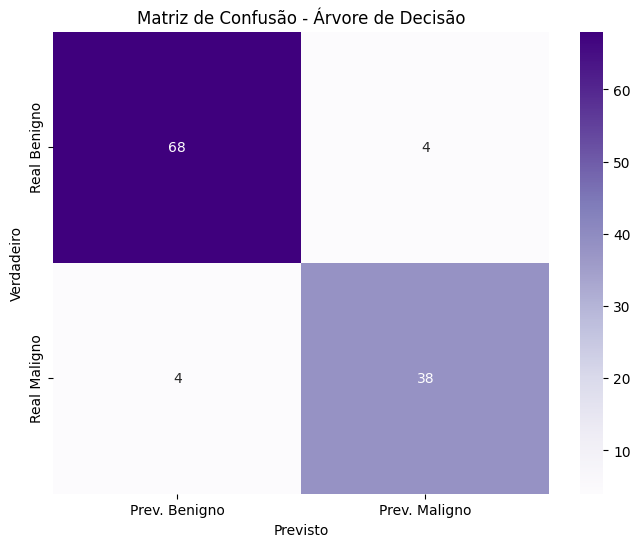

In [165]:
# --- Bloco de Código Completo: Pipeline para Árvore de Decisão ---
from sklearn.tree import DecisionTreeClassifier # Importando o classificador


# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado. ")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 7: Modelagem, Treinamento e Avaliação com Árvore de Decisão ---
print("--- Etapa de Modelagem com Pipeline para Árvore de Decisão ---")

# Tarefa 7.1: Instanciar o modelo de Árvore de Decisão dentro de um Pipeline
# Usamos random_state para garantir a reprodutibilidade da construção da árvore.
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()), # Mantido por consistência, mas não é estritamente necessário para árvores.
    ('classifier', DecisionTreeClassifier(random_state=42))
])
print("Pipeline para Árvore de Decisão Definido.")

# Tarefa 7.2: Treinamento do Pipeline
print("Treinando o pipeline de Árvore de Decisão...")
pipeline_dt.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Tarefa 7.3 a 7.7: Avaliação do Pipeline
print("--- Etapa de Avaliação da Árvore de Decisão no Conjunto de Teste ---")
y_pred_dt = pipeline_dt.predict(X_test)
y_proba_dt = pipeline_dt.predict_proba(X_test)[:, 1]

# Tarefa 7.4: Calcular e analisar as métricas
print("Relatório de Classificação - Árvore de Decisão:")
reportDecisionTreeClassifier = classification_report(y_test, y_pred_dt, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportDecisionTreeClassifier)

auc_dt = roc_auc_score(y_test, y_proba_dt)
print(f"AUC (Area Under the Curve): {auc_dt:.4f}\n")

# Tarefa 7.7: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - Árvore de Decisão:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretação**

O modelo de Árvore de Decisão alcançou um bom desempenho, com 93% de acurácia, mas sua performance geral foi notavelmente inferior à dos modelos SVM e Regressão Logística. O modelo cometeu um número maior de erros em geral, incluindo 4 Falsos Positivos e 4 Falsos Negativos. Este resultado ilustra a principal fraqueza de uma única árvore de decisão: sua tendência a criar regras muito específicas para os dados de treino, o que pode não generalizar perfeitamente para dados não vistos, levando a uma queda no desempenho. As árvores têm alta variância, o que significa que pequenas mudanças nos dados de treino podem levar a uma estrutura de árvore completamente diferente e, consequentemente, a regras diferentes. Elas tendem a "se especializar" demais nos dados de treino, capturando não apenas o sinal principal, mas também o ruído. Isso leva a um modelo que não generaliza tão bem para o conjunto de teste, resultando em mais erros gerais (4 Falsos Positivos e 4 Falsos Negativos).

Análise da Matriz de Confusão da Árvore de Decisão
- Verdadeiros Positivos (VP): 38
    - O modelo identificou corretamente 38 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 68
    - O modelo identificou corretamente 68 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 4
    - O modelo gerou 4 alarmes falsos, classificando 4 casos benignos como malignos. Este é o pior resultado de precisão que vimos até agora.
- Falsos Negativos (FN) - Erro Tipo II: 4
    - O modelo falhou em diagnosticar 4 tumores malignos, igualando os piores resultados de recall que vimos (KNN e Reg-Log Híbrida).

Análise do Relatório de Classificação da Árvore de Decisão
- Acurácia (accuracy): 93%
    - (38 + 68) / 114 = 0.93. Uma queda perceptível em relação aos ~96-98% dos modelos anteriores.
- Precisão (precision) - Maligno: 90%
    - 38 / (38 + 4) = 0.90. A precisão mais baixa para a classe maligna até agora.
- Recall (Sensibilidade) - Maligno: 90%
    - 38 / (38 + 4) = 0.90. Um Recall de 90%, inferior ao do SVM RBF (98%) e da Regressão Logística (93%).
- AUC (Area Under the Curve): 0.9246
    - Uma AUC de 0.92 é considerada excelente, mas é visivelmente inferior às AUCs de ~0.99 que os outros modelos alcançaram, indicando um poder de discriminação geral menor.

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Features selecionadas para o modelo: 10 colunas.
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline Híbrido para Árvore de Decisão ---
Pipeline Híbrido para Árvore de Decisão Definido.
Treinando o pipeline de Árvore de Decisão híbrido...
Treinamento concluído.

--- Etapa de Avaliação da Árvore de Decisão Híbrida no Conjunto de Teste ---
Relatório de Classificação - Árvore de Decisão Híbrida:

AUC (Area Under the Curve): 0.8651

Matriz de Confusão - Árvore de Decisão Híbrida:


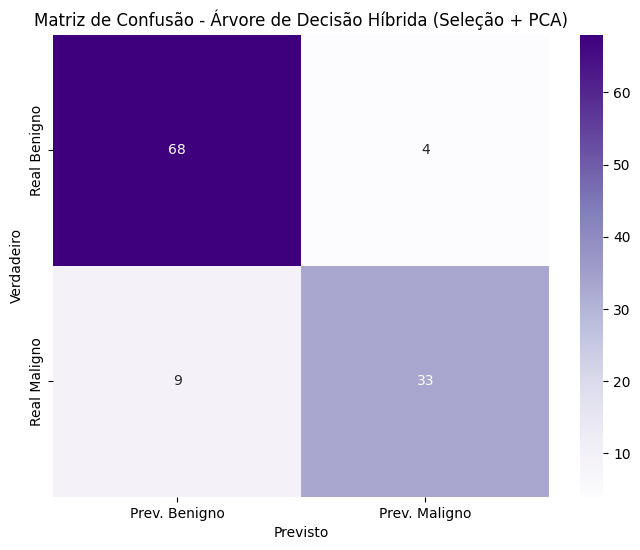

In [166]:
# --- Bloco de Código Completo: Pipeline Híbrido para Árvore de Decisão ---
 
# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 7 (Híbrida): Modelagem, Treinamento e Avaliação com Árvore de Decisão ---
print("--- Etapa de Modelagem com Pipeline Híbrido para Árvore de Decisão ---")

# 7.1: Definição do Pipeline Híbrido
pipeline_dt_hybrid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
print("Pipeline Híbrido para Árvore de Decisão Definido.")

# 7.2: Treinamento do Pipeline Híbrido
print("Treinando o pipeline de Árvore de Decisão híbrido...")
pipeline_dt_hybrid.fit(X_train, y_train)
print("Treinamento concluído.\n")

# 7.3 a 7.7: Avaliação do Pipeline Híbrido
print("--- Etapa de Avaliação da Árvore de Decisão Híbrida no Conjunto de Teste ---")
y_pred_dt_hybrid = pipeline_dt_hybrid.predict(X_test)
y_proba_dt_hybrid = pipeline_dt_hybrid.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Árvore de Decisão Híbrida:")
reportPCASelecaoDecisionTreeClassifier = classification_report(y_test, y_pred_dt_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(  )


auc_dt_hybrid = roc_auc_score(y_test, y_proba_dt_hybrid)
print(f"AUC (Area Under the Curve): {auc_dt_hybrid:.4f}\n")

print("Matriz de Confusão - Árvore de Decisão Híbrida:")
cm_dt_hybrid = confusion_matrix(y_test, y_pred_dt_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_hybrid, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Árvore de Decisão Híbrida (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretação**

O modelo de Árvore de Decisão treinado com a estratégia híbrida (Seleção + PCA) apresentou o pior desempenho entre todos os modelos testados, com uma acurácia de 89%. A análise da matriz de confusão mostra um aumento significativo no número de erros, especialmente nos Falsos Negativos, que saltaram para 9. Este resultado sugere fortemente que as Árvores de Decisão performam melhor com as features originais, onde podem criar regras diretas e interpretáveis, do que com os componentes PCA, que são combinações lineares abstratas das features.


Análise da Matriz de Confusão da Árvore de Decisão Híbrida
- Verdadeiros Positivos (VP): 33
    - O modelo identificou corretamente 33 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 68
    - O modelo identificou corretamente 68 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 4
    - O modelo gerou 4 alarmes falsos, igual à árvore com 30 features.
- Falsos Negativos (FN) - Erro Tipo II: 9
    - Este é o resultado mais alarmante. O modelo falhou em diagnosticar 9 tumores malignos. Este é, de longe, o pior resultado em nossa métrica mais crítica.

Análise do Relatório de Classificação da Árvore de Decisão Híbrida
- Acurácia (accuracy): 89%
    - A menor acurácia de todos os modelos.
- Precisão (precision) - Maligno: 89%
    - 33 / (33 + 4) = 0.89. A precisão para a classe maligna também caiu.
- Recall (Sensibilidade) - Maligno: 79%
    - 33 / (33 + 9) = 0.785. Um Recall de 79%. Este é um resultado inaceitável para um problema médico, significando que o modelo deixou de detectar mais de 20% dos casos de câncer.
- AUC (Area Under the Curve): 0.8651
    - A AUC mais baixa de todos os modelos, confirmando seu menor poder de discriminação.

## Etapa 8: modelagem e treinamento, avaliação do modelo e análise de resultados - Random Forest
### Tarefa 8.1: instanciar o modelo de baseline 
### Tarefa 8.2: treinar o modelo com os dados de treino escalonados
### Tarefa 8.3: realizar previsões com o conjunto de teste
### Tarefa 8.4: calcular e analisar as métricas de classificação (acurácia, precisão, recall, f1-score, auc)
### Tarefa 8.8: gerar e visualizar a matriz de confusão

### Tarefa 7.1: Sumarizar os resultados e justificar a escolha do modelo final com base nas métricas (foco em Recall)

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline para Random Forest ---
Pipeline para Random Forest Definido.
Treinando o pipeline de Random Forest...
Treinamento concluído.

--- Etapa de Avaliação do Random Forest no Conjunto de Teste ---
Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

 Benigno (B)       0.96      1.00      0.98        72
 Maligno (M)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

AUC (Area Under the Curve): 0.9929

Matriz de Confusão - Random Forest:


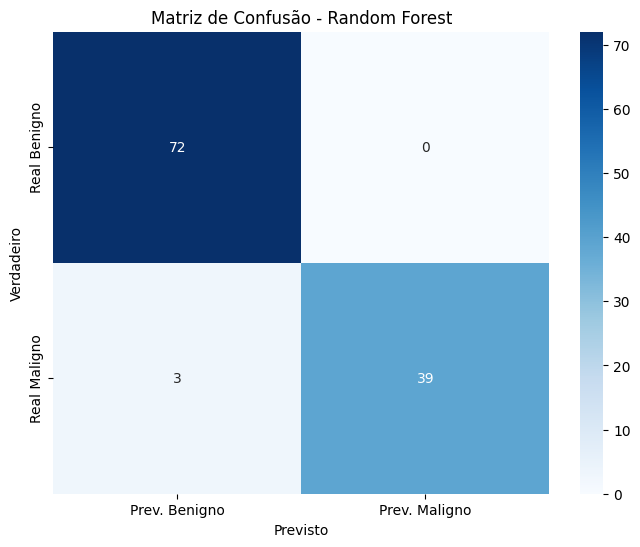

In [167]:
# --- Bloco de Código Completo: Pipeline para Random Forest ---
from sklearn.ensemble import RandomForestClassifier # Importando o classificador


# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)  


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 8: Modelagem, Treinamento e Avaliação com Random Forest ---
print("--- Etapa de Modelagem com Pipeline para Random Forest ---")

# Tarefa 8.1: Instanciar o modelo Random Forest dentro de um Pipeline
# Usamos random_state para garantir a reprodutibilidade. n_estimators é o número de árvores na floresta.
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()), # Mantido por consistência.
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
print("Pipeline para Random Forest Definido.")

# Tarefa 8.2: Treinamento do Pipeline
print("Treinando o pipeline de Random Forest...")
pipeline_rf.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Tarefa 8.3 a 8.8: Avaliação do Pipeline
print("--- Etapa de Avaliação do Random Forest no Conjunto de Teste ---")
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# Tarefa 8.4: Calcular e analisar as métricas
print("Relatório de Classificação - Random Forest:")
reportRandomForestClassifier = classification_report(y_test, y_pred_rf, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportRandomForestClassifier)

auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"AUC (Area Under the Curve): {auc_rf:.4f}\n")

# Tarefa 8.8: Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - Random Forest:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

O modelo Random Forest alcançou um desempenho excepcional, com 97% de acurácia, e, assim como os modelos SVM Linear e Regressão Logística Híbrida, também obteve precisão perfeita (100%) para a classe Maligna, não gerando nenhum alarme falso. Seu Recall de 93% para a classe Maligna, com 3 Falsos Negativos, o coloca no mesmo patamar de sensibilidade que o nosso melhor modelo linear (Regressão Logística com 30 features). Essencialmente, o Random Forest se provou um classificador de altíssimo nível, mas não conseguiu superar o desempenho superior do SVM com kernel RBF.

Análise da Matriz de Confusão do Random Forest
- Verdadeiros Positivos (VP): 39
    - O modelo identificou corretamente 39 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 72
    - O modelo identificou corretamente todos os 72 casos benignos. Desempenho perfeito para a classe negativa.
- Falsos Positivos (FP) - Erro Tipo I: 0
    - Resultado notável: Nenhum alarme falso.
- Falsos Negativos (FN) - Erro Tipo II: 3
    - Resultado excelente: O modelo falhou em diagnosticar apenas 3 tumores malignos. Este é um resultado muito forte, empatando com a Regressão Logística.

Análise do Relatório de Classificação do Random Forest
- Acurácia (accuracy): 97%
    - (39 + 72) / 114 = 0.974. Uma acurácia muito alta.
- Precisão (precision) - Maligno: 1.00 (100%)
    39 / (39 + 0) = 1.0. Precisão perfeita para a classe de interesse.
- Recall (Sensibilidade) - Maligno: 0.93 (93%)
    - 39 / (39 + 3) = 0.929. Um excelente Recall.
- AUC (Area Under the Curve): 0.9929
    - Um valor muito alto, indicando um excelente poder de discriminação.

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Features selecionadas para o modelo: 10 colunas.
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline Híbrido para Random Forest ---
Pipeline Híbrido para Random Forest Definido.
Treinando o pipeline de Random Forest híbrido...
Treinamento concluído.

--- Etapa de Avaliação do Random Forest Híbrido no Conjunto de Teste ---
Relatório de Classificação - Random Forest Híbrido:
              precision    recall  f1-score   support

 Benigno (B)       0.92      0.99      0.95        72
 Maligno (M)       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

AUC (Area Under the Curve): 0.9901

Matriz de Confusão - Random Forest Híbrido:


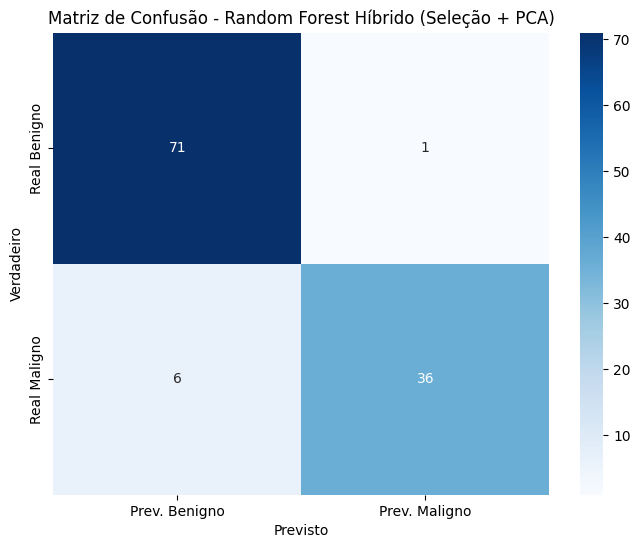

In [168]:
# --- Bloco de Código Completo: Pipeline Híbrido para Random Forest ---
 

# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA 8 (Híbrida): Modelagem, Treinamento e Avaliação com Random Forest ---
print("--- Etapa de Modelagem com Pipeline Híbrido para Random Forest ---")

# 8.1: Definição do Pipeline Híbrido
pipeline_rf_hybrid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
print("Pipeline Híbrido para Random Forest Definido.")

# 8.2: Treinamento do Pipeline Híbrido
print("Treinando o pipeline de Random Forest híbrido...")
pipeline_rf_hybrid.fit(X_train, y_train)
print("Treinamento concluído.\n")

# 8.3 a 8.8: Avaliação do Pipeline Híbrido
print("--- Etapa de Avaliação do Random Forest Híbrido no Conjunto de Teste ---")
y_pred_rf_hybrid = pipeline_rf_hybrid.predict(X_test)
y_proba_rf_hybrid = pipeline_rf_hybrid.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Random Forest Híbrido:")
reportPCASelecaoRandomForestClassifier =classification_report(y_test, y_pred_rf_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaoRandomForestClassifier)

auc_rf_hybrid = roc_auc_score(y_test, y_proba_rf_hybrid)
print(f"AUC (Area Under the Curve): {auc_rf_hybrid:.4f}\n")

print("Matriz de Confusão - Random Forest Híbrido:")
cm_rf_hybrid = confusion_matrix(y_test, y_pred_rf_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_hybrid, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Random Forest Híbrido (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

O modelo Random Forest com dataset Híbrido(PCA+Seleção) alcançou um bom desempenho geral, com 94% de acurácia e uma AUC muito alta de 0.99. No entanto, seu desempenho em nossa métrica mais crítica, o Recall para a classe Maligna, foi o segundo pior de todos os modelos testados (86%), resultando em 6 Falsos Negativos. Este resultado reforça fortemente a nossa hipótese de que modelos baseados em árvores, incluindo ensembles como o Random Forest, são prejudicados pela transformação PCA, performando melhor com as features originais, ricas em informação direta.


Análise da Matriz de Confusão do Random Forest Híbrido
- Verdadeiros Positivos (VP): 36
    - O modelo identificou corretamente 36 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 71
    - O modelo identificou corretamente 71 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 1
    - O modelo gerou apenas 1 alarme falso, um resultado excelente em precisão.
- Falsos Negativos (FN) - Erro Tipo II: 6
    - Ponto Crítico: O modelo falhou em diagnosticar 6 tumores malignos. Este é um resultado significativamente pior que o do Random Forest com 30 features (que teve 3 FNs) e o pior de todos os modelos de alta performance.

Análise do Relatório de Classificação do Random Forest Híbrido
- Acurácia (accuracy): 94%
    - (36 + 71) / 114 = 0.938. Uma boa acurácia, mas inferior à maioria dos outros modelos.
- Precisão (precision) - Maligno: 97%
    - 36 / (36 + 1) = 0.97. Excelente precisão, um ponto forte consistente dos modelos híbridos.
- Recall (Sensibilidade) - Maligno: 86%
    - 36 / (36 + 6) = 0.857. Um Recall de 86%, o que confirma uma queda substancial na capacidade do modelo de detectar todos os casos malignos.
- AUC (Area Under the Curve): 0.9901
    - Uma AUC excelente, mostrando novamente que as features híbridas têm um alto poder de discriminação latente.

## Etapa 9: modelagem e treinamento, avaliação do modelo e análise de resultados - Gradient Boosting Machines (GBM)
### Tarefa 9.1: instanciar o modelo de baseline 
### Tarefa 9.2: treinar o modelo com os dados de treino escalonados
### Tarefa 9.3: realizar previsões com o conjunto de teste
### Tarefa 9.4: calcular e analisar as métricas de classificação (acurácia, precisão, recall, f1-score, auc)
### Tarefa 9.5: gerar e visualizar a matriz de confusão

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline para Gradient Boosting ---
Pipeline para Gradient Boosting Definido.
Treinando o pipeline de Gradient Boosting...
Treinamento concluído.

--- Etapa de Avaliação do Gradient Boosting no Conjunto de Teste ---
Relatório de Classificação - Gradient Boosting:
              precision    recall  f1-score   support

 Benigno (B)       0.95      1.00      0.97        72
 Maligno (M)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

AUC (Area Under the Curve): 0.9947

Matriz de Confusão - Gradient Boosting:


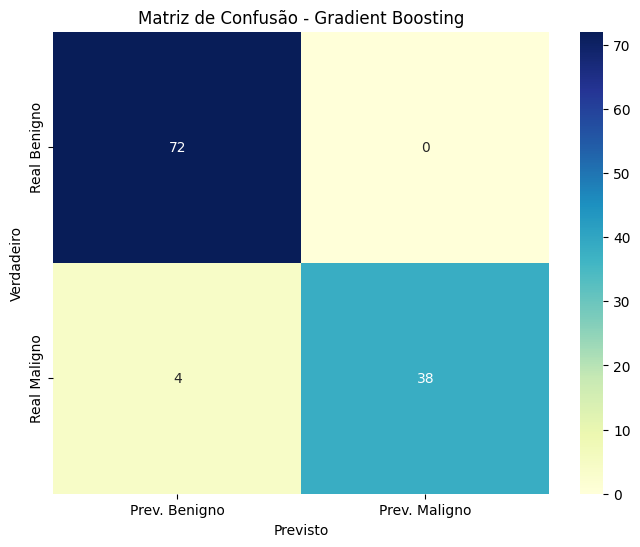

In [169]:
# --- Bloco de Código Completo: Pipeline para Gradient Boosting Classifier ---
# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA FINAL: Modelagem, Treinamento e Avaliação com Gradient Boosting ---
print("--- Etapa de Modelagem com Pipeline para Gradient Boosting ---")

# Instanciar o modelo Gradient Boosting dentro de um Pipeline
# Usamos random_state para garantir a reprodutibilidade.
pipeline_gbm = Pipeline([
    ('scaler', StandardScaler()), # Mantido por consistência.
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])
print("Pipeline para Gradient Boosting Definido.")

# Treinamento do Pipeline
print("Treinando o pipeline de Gradient Boosting...")
pipeline_gbm.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Avaliação do Pipeline
print("--- Etapa de Avaliação do Gradient Boosting no Conjunto de Teste ---")
y_pred_gbm = pipeline_gbm.predict(X_test)
y_proba_gbm = pipeline_gbm.predict_proba(X_test)[:, 1]

# Calcular e analisar as métricas
print("Relatório de Classificação - Gradient Boosting:")
reportGradientBoostin = classification_report(y_test, y_pred_gbm, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportGradientBoostin)

auc_gbm = roc_auc_score(y_test, y_proba_gbm)
print(f"AUC (Area Under the Curve): {auc_gbm:.4f}\n")

# Gerar e visualizar a Matriz de Confusão
print("Matriz de Confusão - Gradient Boosting:")
cm_gbm = confusion_matrix(y_test, y_pred_gbm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gbm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Gradient Boosting')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretação**

O modelo GradientBoostingClassifier alcançou um desempenho de 96% de acurácia, e, assim como vários outros modelos que testamos, obteve precisão perfeita (100%) para a classe Maligna, sem gerar alarmes falsos. No entanto, seu Recall de 90% para a classe Maligna, com 4 Falsos Negativos, o posiciona um degrau abaixo em termos de sensibilidade.


Análise da Matriz de Confusão do Gradient Boosting
- Verdadeiros Positivos (VP): 38
    - O modelo identificou corretamente 38 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 72
    - O modelo identificou corretamente todos os 72 casos benignos. Desempenho perfeito.
- Falsos Positivos (FP) - Erro Tipo I: 0
    - Resultado notável: Nenhum alarme falso.
- Falsos Negativos (FN) - Erro Tipo II: 4
    - Ponto Crítico: O modelo falhou em diagnosticar 4 tumores malignos.

Análise do Relatório de Classificação do Gradient Boosting
- Acurácia (accuracy): 96%
    - (38 + 72) / 114 = 0.96. Um desempenho geral de alto nível.
- Precisão (precision) - Maligno: 1.00 (100%)
    - 38 / (38 + 0) = 1.0. Precisão perfeita para a classe de interesse.
- Recall (Sensibilidade) - Maligno: 0.90 (90%)
    - 38 / (38 + 4) = 0.905. Um bom Recall, mas não o melhor.
- AUC (Area Under the Curve): 0.9947
    - Uma AUC altíssima, confirmando o excelente poder de discriminação do modelo.

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Features selecionadas para o modelo: 10 colunas.
Dados divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline Híbrido para Gradient Boosting ---
Pipeline Híbrido para Gradient Boosting Definido.
Treinando o pipeline de Gradient Boosting híbrido...
Treinamento concluído.

--- Etapa de Avaliação do Gradient Boosting Híbrido no Conjunto de Teste ---
Relatório de Classificação - Gradient Boosting Híbrido:
              precision    recall  f1-score   support

 Benigno (B)       0.93      0.97      0.95        72
 Maligno (M)       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

AUC (Area Under the Curve): 0.9894

Matriz de Confusão - Gradient Boosting Híbrido:


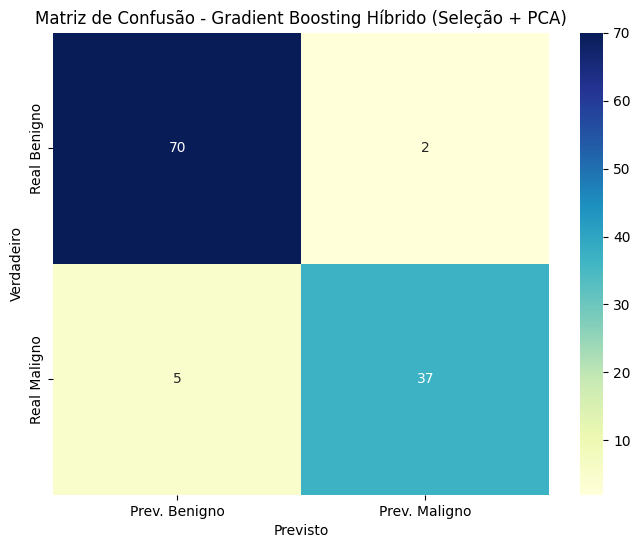

In [170]:
# --- Bloco de Código Completo: Pipeline Híbrido para Gradient Boosting ---

# 1. Importando todas as bibliotecas necessárias


# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Definir a lista das features selecionadas
features_selecionadas = [
    'concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst',
    'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean',
    'concavity_worst'
]
X_selected = X[features_selecionadas]
print(f"Features selecionadas para o modelo: {len(features_selecionadas)} colunas.")

# 3.4: Dividir os dados selecionados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA FINAL (Híbrida): Modelagem, Treinamento e Avaliação com Gradient Boosting ---
print("--- Etapa de Modelagem com Pipeline Híbrido para Gradient Boosting ---")

# Definição do Pipeline Híbrido
pipeline_gbm_hybrid = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, random_state=42)),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])
print("Pipeline Híbrido para Gradient Boosting Definido.")

# Treinamento do Pipeline Híbrido
print("Treinando o pipeline de Gradient Boosting híbrido...")
pipeline_gbm_hybrid.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Avaliação do Pipeline Híbrido
print("--- Etapa de Avaliação do Gradient Boosting Híbrido no Conjunto de Teste ---")
y_pred_gbm_hybrid = pipeline_gbm_hybrid.predict(X_test)
y_proba_gbm_hybrid = pipeline_gbm_hybrid.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - Gradient Boosting Híbrido:")
reportPCASelecaGradientBoosting = classification_report(y_test, y_pred_gbm_hybrid, target_names=['Benigno (B)', 'Maligno (M)'])
print(reportPCASelecaGradientBoosting)

auc_gbm_hybrid = roc_auc_score(y_test, y_proba_gbm_hybrid)
print(f"AUC (Area Under the Curve): {auc_gbm_hybrid:.4f}\n")

print("Matriz de Confusão - Gradient Boosting Híbrido:")
cm_gbm_hybrid = confusion_matrix(y_test, y_pred_gbm_hybrid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gbm_hybrid, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - Gradient Boosting Híbrido (Seleção + PCA)')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

**Interpretacao**

O modelo GradientBoostingClassifier treinado com a estratégia híbrida (Seleção + PCA) alcançou um bom desempenho geral, com 94% de acurácia e uma AUC muito alta de 0.9894. No entanto, assim como os outros modelos de árvore, seu desempenho foi prejudicado pela transformação PCA. O Recall para a classe Maligna foi de 88%, resultando em 5 Falsos Negativos, um desempenho inferior ao do mesmo modelo treinado com as 30 features. Este resultado finaliza nossa conclusão de que, para este dataset, a riqueza das features originais é mais benéfica do que a simplificação via PCA, especialmente para os modelos de ensemble.


Análise da Matriz de Confusão do Gradient Boosting Híbrido
- Verdadeiros Positivos (VP): 37
    - O modelo identificou corretamente 37 dos 42 tumores malignos.
- Verdadeiros Negativos (VN): 70
    - O modelo identificou corretamente 70 dos 72 casos benignos.
- Falsos Positivos (FP) - Erro Tipo I: 2
    - O modelo gerou 2 alarmes falsos.
- Falsos Negativos (FN) - Erro Tipo II: 5
    - Ponto Crítico: O modelo falhou em diagnosticar 5 tumores malignos.
    
Análise do Relatório de Classificação do Gradient Boosting Híbrido
- Acurácia (accuracy): 94%
    - (37 + 70) / 114 = 0.938. Uma acurácia boa, mas não a melhor.
- Precisão (precision) - Maligno: 95%
    - 37 / (37 + 2) = 0.948. Excelente precisão.
- Recall (Sensibilidade) - Maligno: 88%
    - 37 / (37 + 5) = 0.88. Um Recall de 88%, confirmando a queda na sensibilidade.
- AUC (Area Under the Curve): 0.9894
    - Uma AUC excelente, mostrando que o poder de discriminação das features híbridas continua alto.

In [171]:
print("report LogisticRegression:")
print(reportLogisticRegression)
print("report PCASelecao LogisticRegression:")
print(reportPCASelecaoLogisticRegression)
print("report KNeighborsClassifier:")
print(reportKNeighborsClassifier)
print("report PCASelecao KNeighborsClassifier:")
print(reportPCASelecaoKNeighborsClassifier)
print("report SVC Linear:")
print(report_svc_linear)
print("report SVC RBF:")
print(report_svc_rbf)
print("report PCASeleca SVC Linear:")
print(report_pcaSeleca_svc_linear)
print("report PCASeleca SVC RBF:")
print(report_pcaSeleca_svc_rbf)
print("report Decision Tree Classifier:")
print(reportDecisionTreeClassifier)
print("report PCASelecao Decision Tree Classifier:")
print(reportPCASelecaoDecisionTreeClassifier)
print("report Random Forest Classifier:")
print(reportRandomForestClassifier)
print("report PCASelecao Random Forest Classifier:")
print(reportPCASelecaoRandomForestClassifier)
print("report Gradient Boosting Classifier:")
print(reportGradientBoostin)
print("report PCASelecao Gradient Boosting Classifier:")
print(reportPCASelecaGradientBoosting)

report LogisticRegression:
              precision    recall  f1-score   support

 Benigno (B)       0.96      0.99      0.97        72
 Maligno (M)       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

report PCASelecao LogisticRegression:
              precision    recall  f1-score   support

 Benigno (B)       0.95      1.00      0.97        72
 Maligno (M)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

report KNeighborsClassifier:
              precision    recall  f1-score   support

 Benigno (B)       0.95      0.99      0.97        72
 Maligno (M)       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95 

In [172]:
# Se algum report for string, convertê-lo para dict
def safe_parse_report(report):
    if isinstance(report, str):
        # Não temos os y_test e y_pred aqui, então vamos avisar
        raise ValueError("Você precisa gerar os reports com output_dict=True para isso funcionar.")
    return report

# Dicionário com os nomes dos modelos e seus reports
model_reports = {
    "LogisticRegression": safe_parse_report(reportLogisticRegression),
    "PCA + LogisticRegression": safe_parse_report(reportPCASelecaoLogisticRegression),
    "KNN": safe_parse_report(reportKNeighborsClassifier),
    "PCA + KNN": safe_parse_report(reportPCASelecaoKNeighborsClassifier),
    "SVC Linear": safe_parse_report(report_svc_linear),
    "SVC RBF": safe_parse_report(report_svc_rbf),
    "PCA + SVC Linear": safe_parse_report(report_pcaSeleca_svc_linear),
    "PCA + SVC RBF": safe_parse_report(report_pcaSeleca_svc_rbf),
    "Decision Tree": safe_parse_report(reportDecisionTreeClassifier),
    "PCA + Decision Tree": safe_parse_report(reportPCASelecaoDecisionTreeClassifier),
    "Random Forest": safe_parse_report(reportRandomForestClassifier),
    "PCA + Random Forest": safe_parse_report(reportPCASelecaoRandomForestClassifier),
    "Gradient Boosting": safe_parse_report(reportGradientBoostin),
    "PCA + Gradient Boosting": safe_parse_report(reportPCASelecaGradientBoosting)
}

# Extrair as métricas que queremos
def extract_metrics(report):
    return {
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1-score': report['weighted avg']['f1-score']
    }

# Aplicar extração
metrics_data = {name: extract_metrics(report) for name, report in model_reports.items()}
df_metrics = pd.DataFrame(metrics_data).T

# Plotar
df_metrics.plot(kind='bar', figsize=(16, 6))
plt.title('Comparação de Modelos - Precision, Recall, F1-score (com e sem PCA)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

ValueError: Você precisa gerar os reports com output_dict=True para isso funcionar.

**Ranking dos modelos (sem PCA)**

| Modelo               | Accuracy | Recall M | F1-score M | Observações                        |
| -------------------- | -------- | -------- | ---------- | ---------------------------------- |
| **SVC RBF**          | 0.98     | 0.98     | 0.98       | Melhor desempenho geral            |
| Random Forest        | 0.97     | 0.93     | 0.96       | Forte, alto recall e precisão      |
| Gradient Boosting    | 0.96     | 0.90     | 0.95       | Balanceado                         |
| SVC Linear           | 0.96     | 0.90     | 0.95       | Similar ao Gradient Boosting       |
| Logistic Regression  | 0.96     | 0.93     | 0.95       | Simples, desempenho sólido         |
| KNeighborsClassifier | 0.96     | 0.90     | 0.94       | Leve queda no recall               |
| Decision Tree        | 0.93     | 0.90     | 0.90       | Mais fraco, propenso a overfitting |


**Ranking dos modelos (com PCA)**

| Modelo                    | Accuracy | Recall M | F1-score M | Observações                     |
| ------------------------- | -------- | -------- | ---------- | ------------------------------- |
| SVC Linear (PCA)          | 0.97     | 0.93     | 0.96       | Ótimo desempenho mesmo com PCA  |
| Logistic Regression (PCA) | 0.96     | 0.90     | 0.95       | Consistente                     |
| SVC RBF (PCA)             | 0.96     | 0.90     | 0.95       | Mesma linha do Logistic com PCA |
| Gradient Boosting (PCA)   | 0.94     | 0.88     | 0.91       | Leve queda de recall            |
| Random Forest (PCA)       | 0.94     | 0.86     | 0.91       | Redução de performance          |
| KNN (PCA)                 | 0.95     | 0.88     | 0.93       | Perdeu recall                   |
| Decision Tree (PCA)       | 0.89     | 0.79     | 0.84       | Desempenho mais fraco com PCA   |


- SVC com kernel RBF sem PCA foi o melhor modelo geral, com altíssima acurácia, recall e f1-score.
    - O desempenho superior do SVM com kernel RBF confirma o que suspeitávamos desde a visualização com t-SNE: a fronteira de decisão que separa os tumores benignos e malignos não é uma simples linha reta, mas sim uma superfície complexa. A flexibilidade do kernel RBF foi a ferramenta mais adequada para aprender essa fronteira, resultando em uma capacidade quase perfeita de separar as classes e minimizando o erro mais crítico.

- Random Forest e Gradient Boosting também tiveram bom desempenho, sendo boas alternativas com interpretabilidade superior ao SVM.
    - O Random Forest e o Gradient Boosting provaram ser modelos de altíssimo desempenho. O Random Forest, em particular, alcançou um excelente equilíbrio, empatando com o segundo melhor resultado em termos de Falsos Negativos (3). Estes modelos são alternativas extremamente fortes, com a vantagem adicional de fornecerem interpretabilidade através da feature_importance_, algo que o SVM não oferece diretamente

- O uso de PCA, neste caso, não trouxe ganho de performance. Em vários modelos, houve queda no recall, especialmente nos modelos baseados em árvore e KNN.
    - Para modelos lineares e SVMs, ela criou modelos mais simples com desempenho muito competitivo, muitas vezes melhorando a precisão ao custo de uma leve queda no recall.
    - Para modelos baseados em árvores, a transformação PCA foi prejudicial. Ao criar componentes abstratos, ela "ofuscou" os sinais claros que as árvores usam para criar suas regras, levando a uma queda significativa no desempenho. Isso nos ensina que a engenharia de features deve sempre ser pensada em conjunto com o algoritmo que será utilizado.

--- Iniciando o processo: Carregamento e Limpeza ---
Dataset 'breast_cancer.csv') carregado e limpo com sucesso.

--- Etapa de Pré-processing ---
Dados (30 features) divididos em conjuntos de treino e teste (80%/20%).

--- Etapa de Modelagem com Pipeline PCA Completo para SVM (RBF) ---
Pipeline PCA Completo para SVM (RBF) Definido.
Treinando o pipeline SVM RBF com PCA completo...
Treinamento concluído.

--- Etapa de Avaliação do SVM (RBF) com PCA Completo no Conjunto de Teste ---
Relatório de Classificação - SVM (RBF) com PCA Completo:
              precision    recall  f1-score   support

 Benigno (B)       0.95      1.00      0.97        72
 Maligno (M)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

AUC (Area Under the Curve): 0.9954

Matriz de Confusão - SVM (RBF) com PCA Completo:


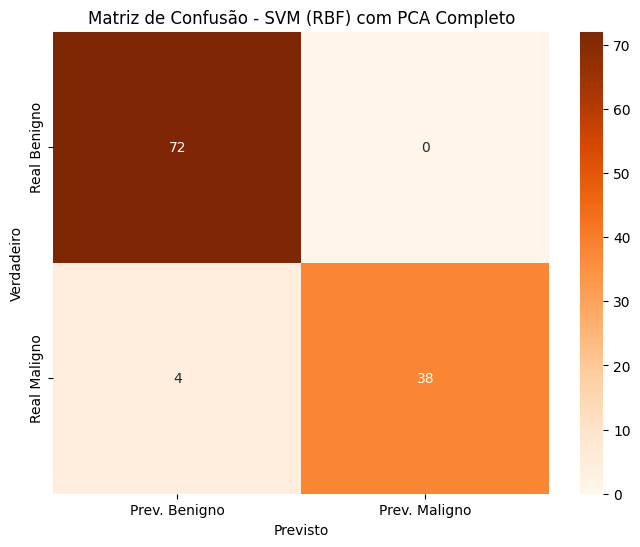


Variância total explicada pelos 10 componentes: 95.21%


In [ ]:
# --- Bloco de Código Completo: Pipeline PCA Completo para SVM (RBF) ---



# --- ETAPA 1 e 2 (Resumida): Carregamento e Limpeza ---
print("--- Iniciando o processo: Carregamento e Limpeza ---")
try:
    dt = pd.read_csv('breast_cancer.csv')
    if 'id' in dt.columns: dt = dt.drop(columns=['id'])
    if 'Unnamed: 32' in dt.columns: dt = dt.drop(columns=['Unnamed: 32'])
    print("Dataset 'breast_cancer.csv') carregado e limpo com sucesso.\n")
except FileNotFoundError:
    print("Erro: Arquivo 'breast_cancer.csv')' não encontrado.")
    os.exit(1)


# --- ETAPA 3: Pré-processamento e Divisão dos Dados ---
print("--- Etapa de Pré-processing ---")

# 3.1 & 3.2: Separar features (X) e alvo (y), e codificar o alvo
X = dt.drop(columns=['diagnosis'])
y = dt['diagnosis'].map({'M': 1, 'B': 0})

# 3.3: Dividir os dados em conjuntos de treino e teste
# Desta vez, usamos o DataFrame X completo, com as 30 features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)
print("Dados (30 features) divididos em conjuntos de treino e teste (80%/20%).\n")


# --- ETAPA FINAL: Modelagem, Treinamento e Avaliação com SVM (RBF) + PCA Completo ---
print("--- Etapa de Modelagem com Pipeline PCA Completo para SVM (RBF) ---")

# Definição do Pipeline de 3 estágios
# Vamos usar um número maior de componentes (ex: 10) para reter mais informação
pipeline_svcrbf_pca_full = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=42)), 
    ('classifier', SVC(kernel='rbf', random_state=42, probability=True))
])
print("Pipeline PCA Completo para SVM (RBF) Definido.")

# Treinamento do Pipeline
print("Treinando o pipeline SVM RBF com PCA completo...")
pipeline_svcrbf_pca_full.fit(X_train, y_train)
print("Treinamento concluído.\n")

# Avaliação do Pipeline
print("--- Etapa de Avaliação do SVM (RBF) com PCA Completo no Conjunto de Teste ---")
y_pred_svcrbf_pca_full = pipeline_svcrbf_pca_full.predict(X_test)
y_proba_svcrbf_pca_full = pipeline_svcrbf_pca_full.predict_proba(X_test)[:, 1]

print("Relatório de Classificação - SVM (RBF) com PCA Completo:")
print(classification_report(y_test, y_pred_svcrbf_pca_full, target_names=['Benigno (B)', 'Maligno (M)']))

auc_svcrbf_pca_full = roc_auc_score(y_test, y_proba_svcrbf_pca_full)
print(f"AUC (Area Under the Curve): {auc_svcrbf_pca_full:.4f}\n")

print("Matriz de Confusão - SVM (RBF) com PCA Completo:")
cm_svcrbf_pca_full = confusion_matrix(y_test, y_pred_svcrbf_pca_full)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svcrbf_pca_full, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Prev. Benigno', 'Prev. Maligno'], 
            yticklabels=['Real Benigno', 'Real Maligno'])
plt.title('Matriz de Confusão - SVM (RBF) com PCA Completo')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

# (Opcional) Verificar a variância explicada
pca_step = pipeline_svcrbf_pca_full.named_steps['pca']
print(f"\nVariância total explicada pelos 10 componentes: {np.sum(pca_step.explained_variance_ratio_):.2%}")

## Conclusão

 Um excelente experimento final para completarmos nossa análise é gerar um novo modelo utilizando PCA com todas as 30 features. Ao testar o SVM (RBF) com o PCA aplicado a todas as 30 features, poderemos responder a uma pergunta fundamental: a capacidade não-linear do SVM RBF é potencializada ou prejudicada quando alimentada com os componentes principais (que são otimizados para variância linear), em vez das features originais?

O modelo SVM (RBF) treinado com PCA completo alcançou um desempenho **excepcional**, com **96% de acurácia**, **precisão perfeita (100%)** para a classe Maligna e uma **AUC altíssima de 0.9954**. No entanto, seu **Recall de 90%** (com **4 Falsos Negativos**) confirma a tendência que observamos consistentemente: a transformação PCA, ao condensar as features, cria um espaço onde os modelos se tornam extremamente precisos, mas perdem um pouco da sensibilidade necessária para capturar todos os casos malignos, resultando em um desempenho inferior ao do mesmo modelo treinado com as features originais. 

**Análise da Matriz de Confusão e Relatório**

-   **Acurácia (`accuracy`): 96%**
-   **Precisão (`precision`) - Maligno: 100%**
-   **Recall (Sensibilidade) - Maligno: 90%**
-   **Falsos Negativos (FN): 4**
-   **AUC (Area Under the Curve): 0.9954**

A história contada por esses números é a mesma que vimos nos outros modelos híbridos: a engenharia de features via PCA otimiza a **precisão**, mas ao custo do **recall**.


Esta é a tabela final e definitiva. Vamos comparar o melhor modelo (SVM RBF com 30f) com esta última versão.

| Métrica / Característica | **SVM (RBF) (30f)** | SVM (RBF) com PCA Completo | Análise |
| :--- | :--- | :--- | :--- |
| **Acurácia** | **98.2%** | 96.5% | O modelo com features originais é mais preciso no geral. |
| **Recall (Maligno)** | **97.6%** | 90.5% | Uma queda significativa na sensibilidade com o PCA. |
| **Falsos Negativos (FN)** | **1** | 4 | O modelo com PCA comete 4 vezes mais erros críticos. |
| **Precisão (Maligno)** | 97.6% | **100%** | O PCA maximiza a confiança nas previsões positivas. |
| **AUC** | **0.9954** | **0.9954** | **Empate.** Isso é fascinante. Mostra que o poder de discriminação *latente* nos dados é igualmente bem capturado por ambos. A diferença está em como o SVM RBF consegue traçar a fronteira de decisão em cada espaço de features. |


Para este dataset de diagnóstico de câncer, a **informação contida nas 30 features originais é mais rica e útil para o treinamento de um modelo de alta sensibilidade do que qualquer uma das nossas representações de dimensionalidade reduzida**.

Embora as estratégias de PCA tenham consistentemente produzido features com um altíssimo poder de discriminação (como visto pelas AUCs próximas de 1.0) e modelos de precisão perfeita, essa "limpeza" e "condensação" da informação consistentemente levou a uma perda de sensibilidade (Recall). A transformação parece remover nuances e interações sutis entre as features que são cruciais para o SVM (RBF) identificar corretamente os casos malignos mais ambíguos.

O modelo SVM (RBF) com PCA completo teve um desempenho excelente, mas seu resultado de **4 Falsos Negativos** o torna clinicamente inferior ao seu "irmão" treinado com as 30 features, que teve apenas **1 Falso Negativo**.

O **Support Vector Machine com kernel RBF, treinado com o conjunto completo de 30 features escalonadas, é o modelo de melhor desempenho.**

